## IMPORTS & SETTINGS

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import shap
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier

from sklearn.model_selection import (
    train_test_split,
    RepeatedStratifiedKFold,
    cross_val_score,
    learning_curve,
    StratifiedKFold
)

from sklearn.preprocessing import StandardScaler, label_binarize, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, matthews_corrcoef,
    cohen_kappa_score, log_loss, confusion_matrix,
    roc_curve, auc
)
from imblearn.over_sampling import SMOTE

# ── Global plot settings ──────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi':        150,
    'savefig.dpi':       300,
    'font.family':       'DejaVu Sans',
    'font.size':         11,
    'axes.titlesize':    13,
    'axes.labelsize':    11,
    'xtick.labelsize':   10,
    'ytick.labelsize':   10,
    'legend.fontsize':   10,
    'figure.facecolor':  'white',
    'axes.facecolor':    '#F8F9FA',
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'grid.color':        '#CCCCCC',
    'axes.spines.top':   False,
    'axes.spines.right': False,
})

PALETTE = ['#27AE60', '#F39C12', '#E74C3C']   # Low=green, Med=orange, High=red

MODEL_COLORS = {
    'LR':  '#2980B9',   # blue
    'RF':  '#27AE60',   # green
    'GB':  '#C0392B',   # red
    'SVM': '#8E44AD',   # purple
    'MLP': '#E67E22',   # orange
}
MODEL_COLORS_LIST = list(MODEL_COLORS.values())   # ordered list

MODEL_CMAPS = {
    'LR':  'Blues',
    'RF':  'Greens',
    'GB':  'Reds',
    'SVM': 'Purples',
    'MLP': 'Oranges',
}

RANDOM_STATE = 42

print("All libraries imported successfully.")

All libraries imported successfully.


## LOAD & INSPECT DATA

In [2]:
df1 = pd.read_csv('Stress_Dataset.csv')
df2 = pd.read_csv('StressLevelDataset.csv')

print("=" * 55)
print("DATASET 1 — Stress_Dataset (raw)")
print("=" * 55)
print(f"Shape   : {df1.shape}")
print(f"Missing : {df1.isnull().sum().sum()}")
print(f"Age range: {df1['Age'].min()} – {df1['Age'].max()}")
print(f"\nTarget distribution:")
print(df1['Which type of stress do you primarily experience?'].value_counts())

print("\n" + "=" * 55)
print("DATASET 2 — StressLevelDataset")
print("=" * 55)
print(f"Shape   : {df2.shape}")
print(f"Missing : {df2.isnull().sum().sum()}")
print(f"\nTarget distribution:")
print(df2['stress_level'].value_counts().sort_index()
      .rename({0: 'Low (0)', 1: 'Medium (1)', 2: 'High (2)'}))

DATASET 1 — Stress_Dataset (raw)
Shape   : (843, 26)
Missing : 0
Age range: 14 – 100

Target distribution:
Which type of stress do you primarily experience?
Eustress (Positive Stress) - Stress that motivates and enhances performance.       768
No Stress - Currently experiencing minimal to no stress.                            43
Distress (Negative Stress) - Stress that causes anxiety and impairs well-being.     32
Name: count, dtype: int64

DATASET 2 — StressLevelDataset
Shape   : (1100, 21)
Missing : 0

Target distribution:
stress_level
Low (0)       373
Medium (1)    358
High (2)      369
Name: count, dtype: int64


## PREPROCESSING

In [3]:
# ── Dataset 1: filter to age 18–22 only ──────────────────────────────────────
df1_clean = df1[(df1['Age'] >= 18) & (df1['Age'] <= 22)].copy()
print(f"\nDataset 1 after age filter (18–22): {len(df1_clean)} students")

# Short stress labels
stress_labels_df1 = {
    'Distress (Negative Stress) - Stress that causes anxiety and impairs well-being.': 'Distress',
    'Eustress (Positive Stress) - Stress that motivates and enhances performance.'   : 'Eustress',
    'No Stress - Currently experiencing minimal to no stress.'                        : 'No Stress',
}
df1_clean['stress_type_short'] = (
    df1_clean['Which type of stress do you primarily experience?'].map(stress_labels_df1)
)

# Rename symptom columns for readability
col_mapping_df1 = {
    'Have you recently experienced stress in your life?'            : 'recent_stress',
    'Have you noticed a rapid heartbeat or palpitations?'           : 'palpitations',
    'Have you been dealing with anxiety or tension recently?'       : 'anxiety',
    'Do you face any sleep problems or difficulties falling asleep?' : 'sleep_problems',
    'Have you been dealing with anxiety or tension recently?.1'     : 'tension',
    'Have you been getting headaches more often than usual?'        : 'headaches',
    'Do you get irritated easily?'                                  : 'irritability',
    'Do you have trouble concentrating on your academic tasks?'     : 'concentration',
    'Have you been feeling sadness or low mood?'                    : 'low_mood',
    'Have you been experiencing any illness or health issues?'      : 'illness',
    'Do you often feel lonely or isolated?'                         : 'loneliness',
    'Do you feel overwhelmed with your academic workload?'          : 'academic_overload',
    'Are you in competition with your peers, and does it affect you?': 'peer_competition',
    'Do you find that your relationship often causes you stress?'   : 'relationship_stress',
    'Are you facing any difficulties with your professors or instructors?': 'prof_difficulties',
    'Is your working environment unpleasant or stressful?'          : 'work_environment',
    'Do you struggle to find time for relaxation and leisure activities?': 'no_leisure',
    'Is your hostel or home environment causing you difficulties?'  : 'home_difficulties',
    'Do you lack confidence in your academic performance?'          : 'academic_confidence',
    'Do you lack confidence in your choice of academic subjects?'   : 'subject_confidence',
    'Academic and extracurricular activities conflicting for you?'  : 'activity_conflict',
    'Do you attend classes regularly?'                              : 'class_attendance',
    'Have you gained/lost weight?'                                  : 'weight_change',
}
df1_clean = df1_clean.rename(columns=col_mapping_df1)

# ── SMOTE for Dataset 1 ───────────────────────────────────────────────────────
le1 = LabelEncoder()
df1_clean['stress_type_encoded'] = le1.fit_transform(df1_clean['stress_type_short'])

symptom_cols_smote = [
    'recent_stress', 'palpitations', 'anxiety', 'sleep_problems', 'tension',
    'headaches', 'irritability', 'concentration', 'low_mood', 'illness',
    'loneliness', 'academic_overload', 'peer_competition', 'relationship_stress',
    'prof_difficulties', 'work_environment', 'no_leisure', 'home_difficulties',
    'academic_confidence', 'subject_confidence', 'activity_conflict',
    'class_attendance', 'weight_change',
]
symptom_cols_smote = [c for c in symptom_cols_smote if c in df1_clean.columns]

X_df1 = df1_clean[symptom_cols_smote]
y_df1 = df1_clean['stress_type_encoded']

print(f"\nDataset 1 BEFORE SMOTE:")
before_counts = y_df1.value_counts().sort_index()
for idx, cnt in before_counts.items():
    print(f"  {le1.classes_[idx]:<15}: {cnt}")

smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=3)
X_df1_smote, y_df1_smote = smote.fit_resample(X_df1, y_df1)

print(f"\nDataset 1 AFTER SMOTE:")
after_counts = pd.Series(y_df1_smote).value_counts().sort_index()
for idx, cnt in after_counts.items():
    print(f"  {le1.classes_[idx]:<15}: {cnt}")

# ── Dataset 2: features / split / scale ──────────────────────────────────────
rename_map = {
    'anxiety_level'               : 'Anxiety',
    'self_esteem'                 : 'Self-Esteem',
    'mental_health_history'       : 'MH History',
    'depression'                  : 'Depression',
    'headache'                    : 'Headache',
    'blood_pressure'              : 'Blood Pressure',
    'sleep_quality'               : 'Sleep Quality',
    'breathing_problem'           : 'Breathing',
    'noise_level'                 : 'Noise Level',
    'living_conditions'           : 'Living Cond.',
    'safety'                      : 'Safety',
    'basic_needs'                 : 'Basic Needs',
    'academic_performance'        : 'Acad. Perf.',
    'study_load'                  : 'Study Load',
    'teacher_student_relationship': 'Teacher Rel.',
    'future_career_concerns'      : 'Career Concern',
    'social_support'              : 'Social Support',
    'peer_pressure'               : 'Peer Pressure',
    'extracurricular_activities'  : 'Extracurricular',
    'bullying'                    : 'Bullying',
    'stress_level'                : 'Stress Level',
}

feature_cols = [c for c in df2.columns if c != 'stress_level']
X = df2[feature_cols].copy()
y = df2['stress_level'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_s = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_cols)
X_test_s  = pd.DataFrame(scaler.transform(X_test),      columns=feature_cols)

print("\nPreprocessing complete.")
print(f"  df1 (18–22, after SMOTE) : {X_df1_smote.shape[0]} samples, {X_df1_smote.shape[1]} features")
print(f"  X_train / X_test         : {X_train.shape} / {X_test.shape}")


Dataset 1 after age filter (18–22): 777 students

Dataset 1 BEFORE SMOTE:
  Distress       : 29
  Eustress       : 710
  No Stress      : 38

Dataset 1 AFTER SMOTE:
  Distress       : 710
  Eustress       : 710
  No Stress      : 710

Preprocessing complete.
  df1 (18–22, after SMOTE) : 2130 samples, 23 features
  X_train / X_test         : (880, 20) / (220, 20)


## FIGURE 1: Stress Distribution — Both Datasets  (SMOTE included)

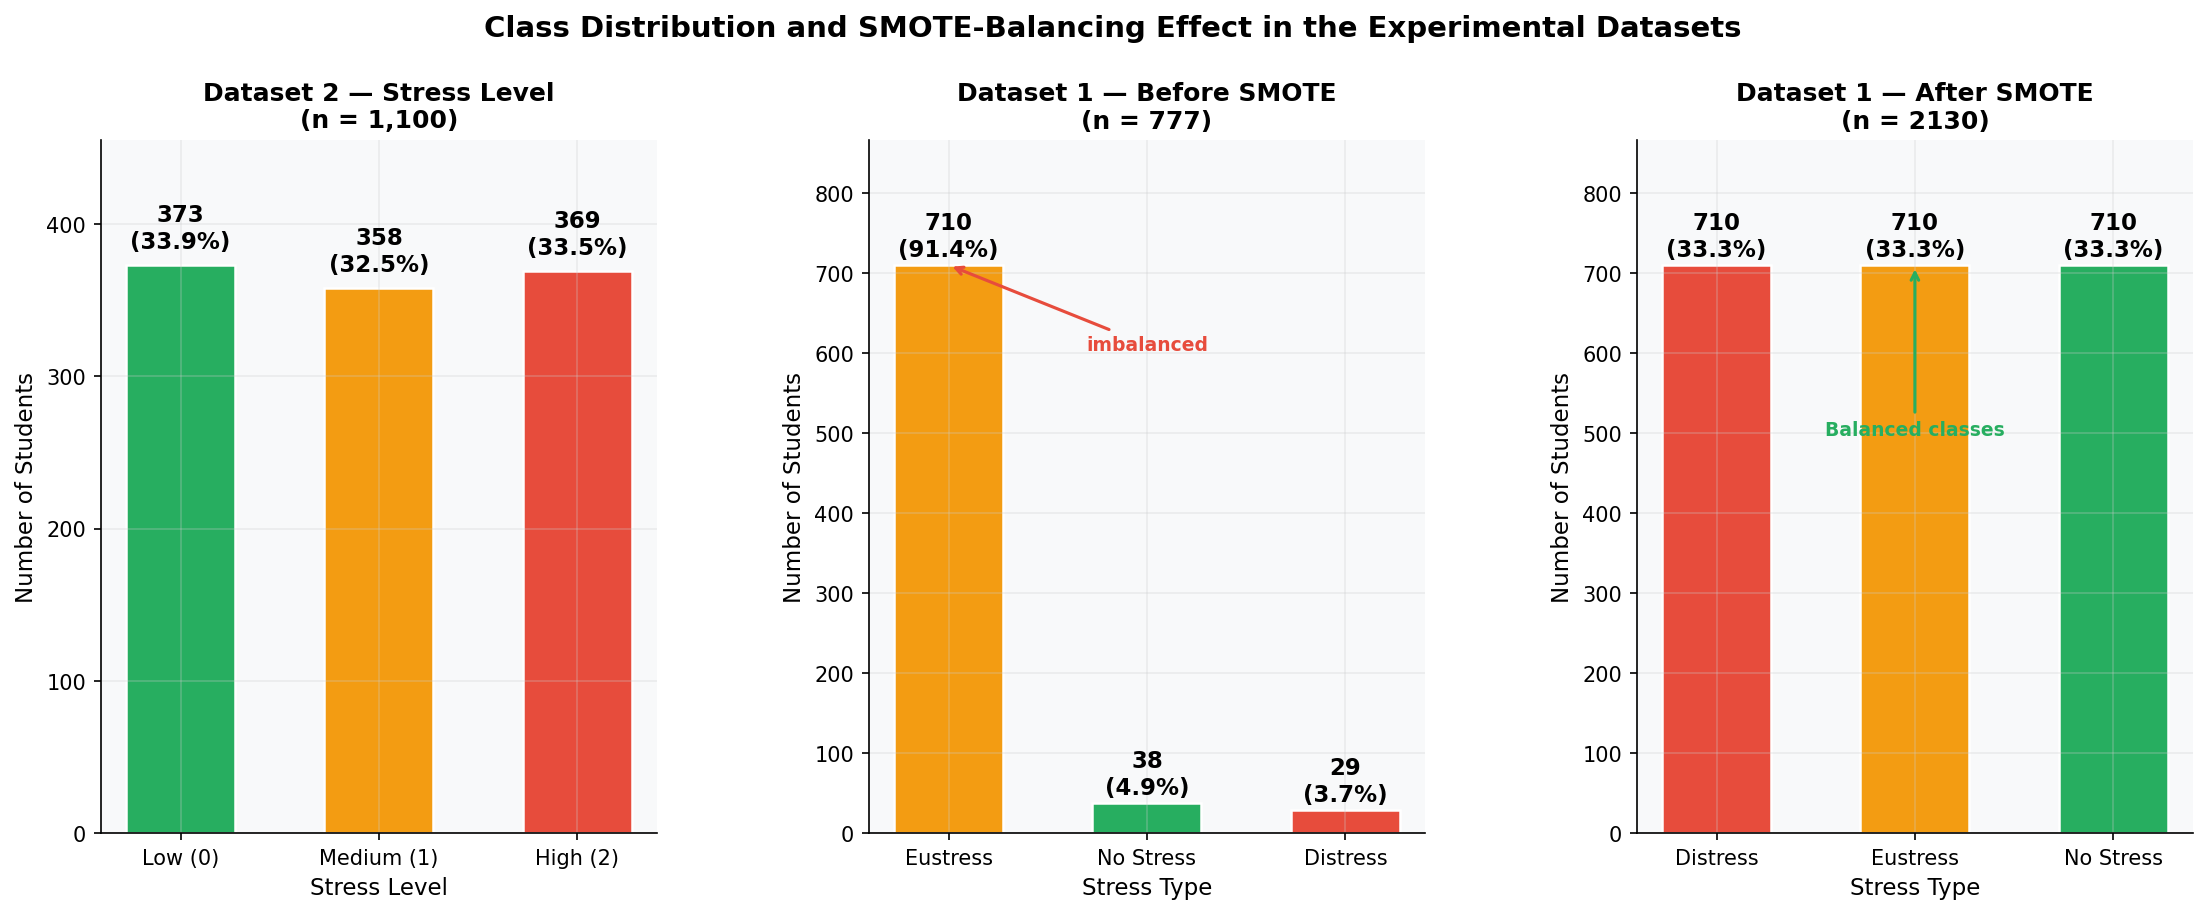

Figure 1 saved.


In [4]:
fig = plt.figure(figsize=(18, 6))
fig.suptitle('Class Distribution and SMOTE-Balancing Effect in the Experimental Datasets\n',
    fontsize=14, fontweight='bold', y=1.02
)
gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.38)

# ── Left: Dataset 2 — Stress Level (0/1/2) ───────────────────────────────────
ax0 = fig.add_subplot(gs[0])
level_counts = df2['stress_level'].value_counts().sort_index()
level_labels = ['Low (0)', 'Medium (1)', 'High (2)']
bars = ax0.bar(level_labels, level_counts.values,
               color=PALETTE, edgecolor='white', linewidth=1.2, width=0.55)
for bar, count in zip(bars, level_counts.values):
    pct = count / len(df2) * 100
    ax0.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 8,
             f'{count}\n({pct:.1f}%)',
             ha='center', va='bottom', fontsize=11, fontweight='bold')
ax0.set_title('Dataset 2 — Stress Level\n(n = 1,100)',
              fontsize=12, fontweight='bold')
ax0.set_xlabel('Stress Level'); ax0.set_ylabel('Number of Students')
ax0.set_ylim(0, level_counts.max() * 1.22)

# ── Middle: Dataset 1 BEFORE SMOTE ───────────────────────────────────────────
ax1 = fig.add_subplot(gs[1])
stress_order_short = ['Eustress', 'No Stress', 'Distress']
type_colors        = {'Eustress': '#F39C12', 'No Stress': '#27AE60', 'Distress': '#E74C3C'}
before_series = df1_clean['stress_type_short'].value_counts().reindex(stress_order_short, fill_value=0)

bars1 = ax1.bar(stress_order_short, before_series.values,
                color=[type_colors[s] for s in stress_order_short],
                edgecolor='white', linewidth=1.2, width=0.55)
for bar, count in zip(bars1, before_series.values):
    pct = count / before_series.sum() * 100
    ax1.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 5,
             f'{count}\n({pct:.1f}%)',
             ha='center', va='bottom', fontsize=11, fontweight='bold')
ax1.set_title('Dataset 1 — Before SMOTE\n(n = 777)',
              fontsize=12, fontweight='bold')
ax1.set_xlabel('Stress Type'); ax1.set_ylabel('Number of Students')
ax1.set_ylim(0, before_series.max() * 1.22)

# Add imbalance annotation
ax1.annotate('imbalanced',
             xy=(0, before_series['Eustress']),
             xytext=(1, before_series['Eustress'] * 0.85),
             arrowprops=dict(arrowstyle='->', color='#E74C3C', lw=1.5),
             fontsize=9, color='#E74C3C', fontweight='bold', ha='center')

# ── Right: Dataset 1 AFTER SMOTE ─────────────────────────────────────────────
ax2 = fig.add_subplot(gs[2])
after_class_names  = le1.classes_                         # sorted alphabetically
after_series_vals  = pd.Series(y_df1_smote).value_counts().sort_index().values
after_labels       = [le1.classes_[i] for i in pd.Series(y_df1_smote).value_counts().sort_index().index]

# Map to short names same order
short_map = {'Distress': 'Distress', 'Eustress': 'Eustress', 'No Stress': 'No Stress'}
after_labels_short = [short_map.get(l, l) for l in after_labels]

bars2 = ax2.bar(after_labels_short, after_series_vals,
                color=[type_colors.get(l, '#888') for l in after_labels_short],
                edgecolor='white', linewidth=1.2, width=0.55)
for bar, count in zip(bars2, after_series_vals):
    pct = count / after_series_vals.sum() * 100
    ax2.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 5,
             f'{count}\n({pct:.1f}%)',
             ha='center', va='bottom', fontsize=11, fontweight='bold')
ax2.set_title(f'Dataset 1 — After SMOTE\n(n = {after_series_vals.sum()})',
              fontsize=12, fontweight='bold')
ax2.set_xlabel('Stress Type'); ax2.set_ylabel('Number of Students')
ax2.set_ylim(0, after_series_vals.max() * 1.22)

ax2.annotate('Balanced classes',
             xy=(1, after_series_vals[1]),
             xytext=(1, after_series_vals.max() * 0.7),
             arrowprops=dict(arrowstyle='->', color='#27AE60', lw=1.5),
             fontsize=9, color='#27AE60', fontweight='bold', ha='center')

plt.tight_layout()
plt.savefig('fig1_stress_distribution.png', bbox_inches='tight', dpi=300)
plt.show()
print("Figure 1 saved.")

## FIGURE 2: Spearman Correlation Heatmap (Dataset 2)

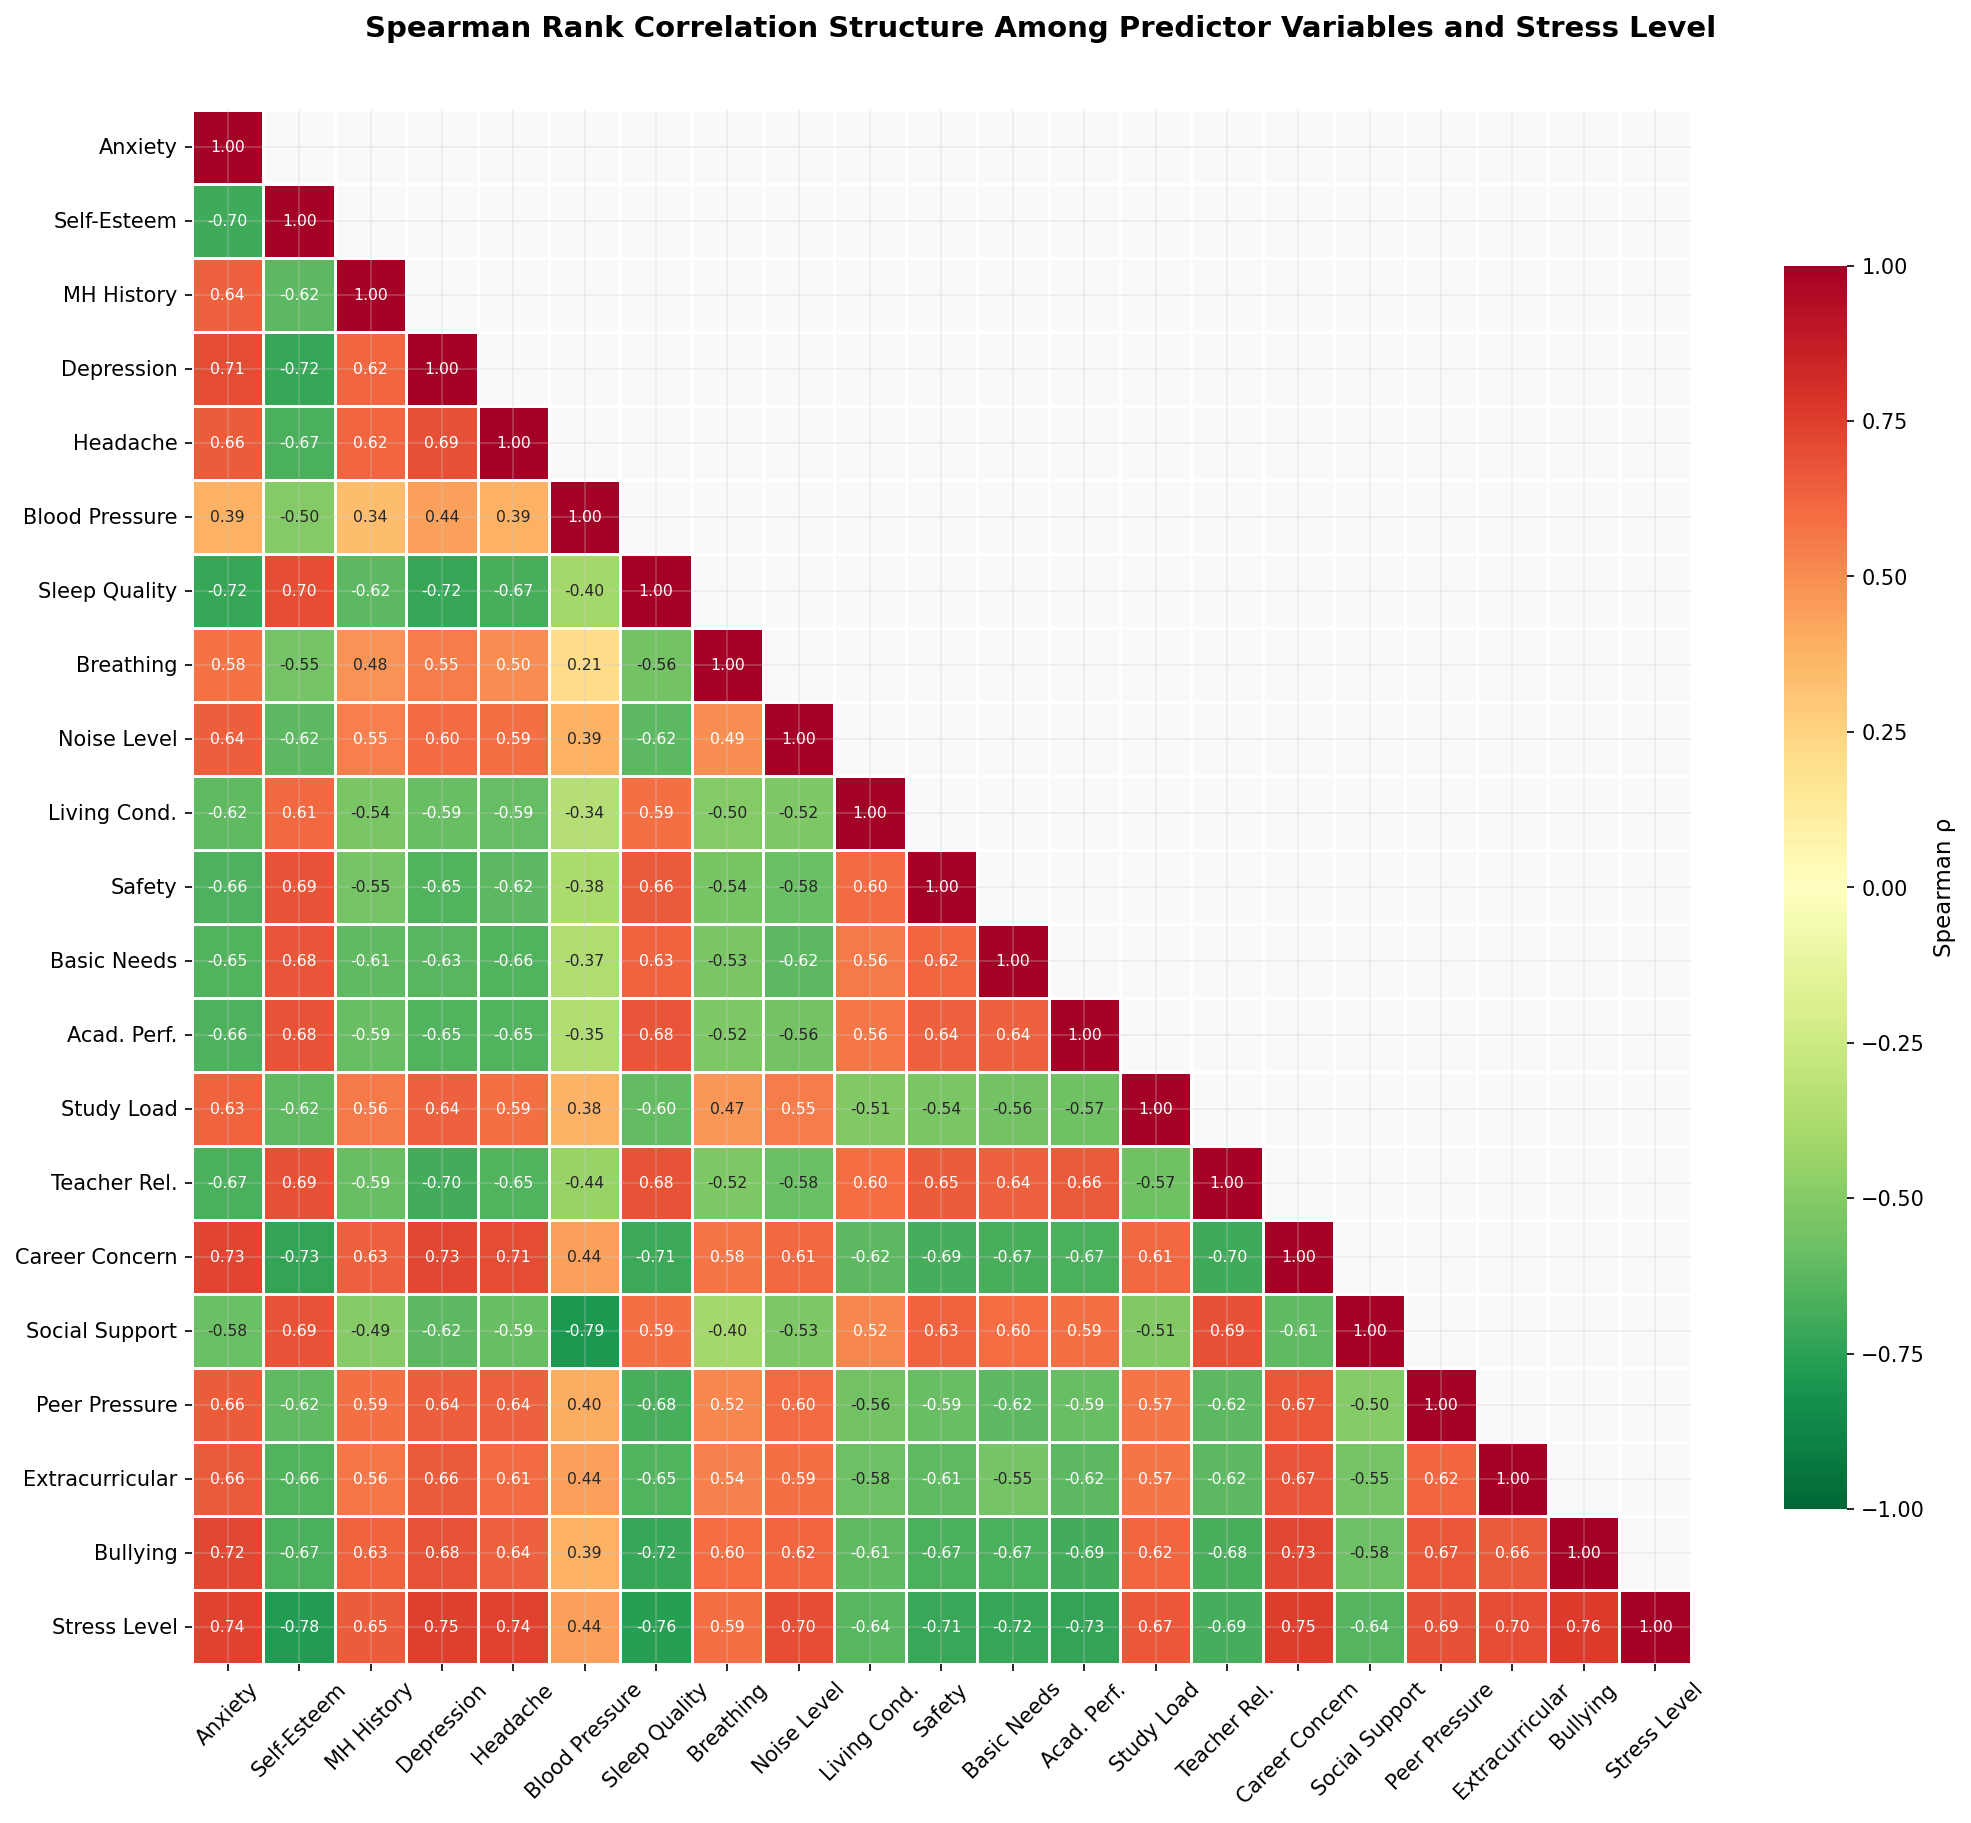

Figure 2 saved.


In [5]:
fig, ax = plt.subplots(figsize=(14, 12))
fig.suptitle('Spearman Rank Correlation Structure Among Predictor Variables and Stress Level',
             fontsize=14, fontweight='bold', y=1.01)

corr_plot = df2.rename(columns=rename_map).corr(method='spearman')
mask = np.triu(np.ones_like(corr_plot, dtype=bool), k=1)

sns.heatmap(
    corr_plot, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn_r', center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor='white',
    annot_kws={'size': 7.5},
    cbar_kws={'shrink': 0.8, 'label': 'Spearman ρ'},
    ax=ax
)
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('fig2_correlation_heatmap.png', bbox_inches='tight', dpi=300)
plt.show()
print("Figure 2 saved.")

## FIGURE 3: Feature Distribution Boxplots (Dataset 2)

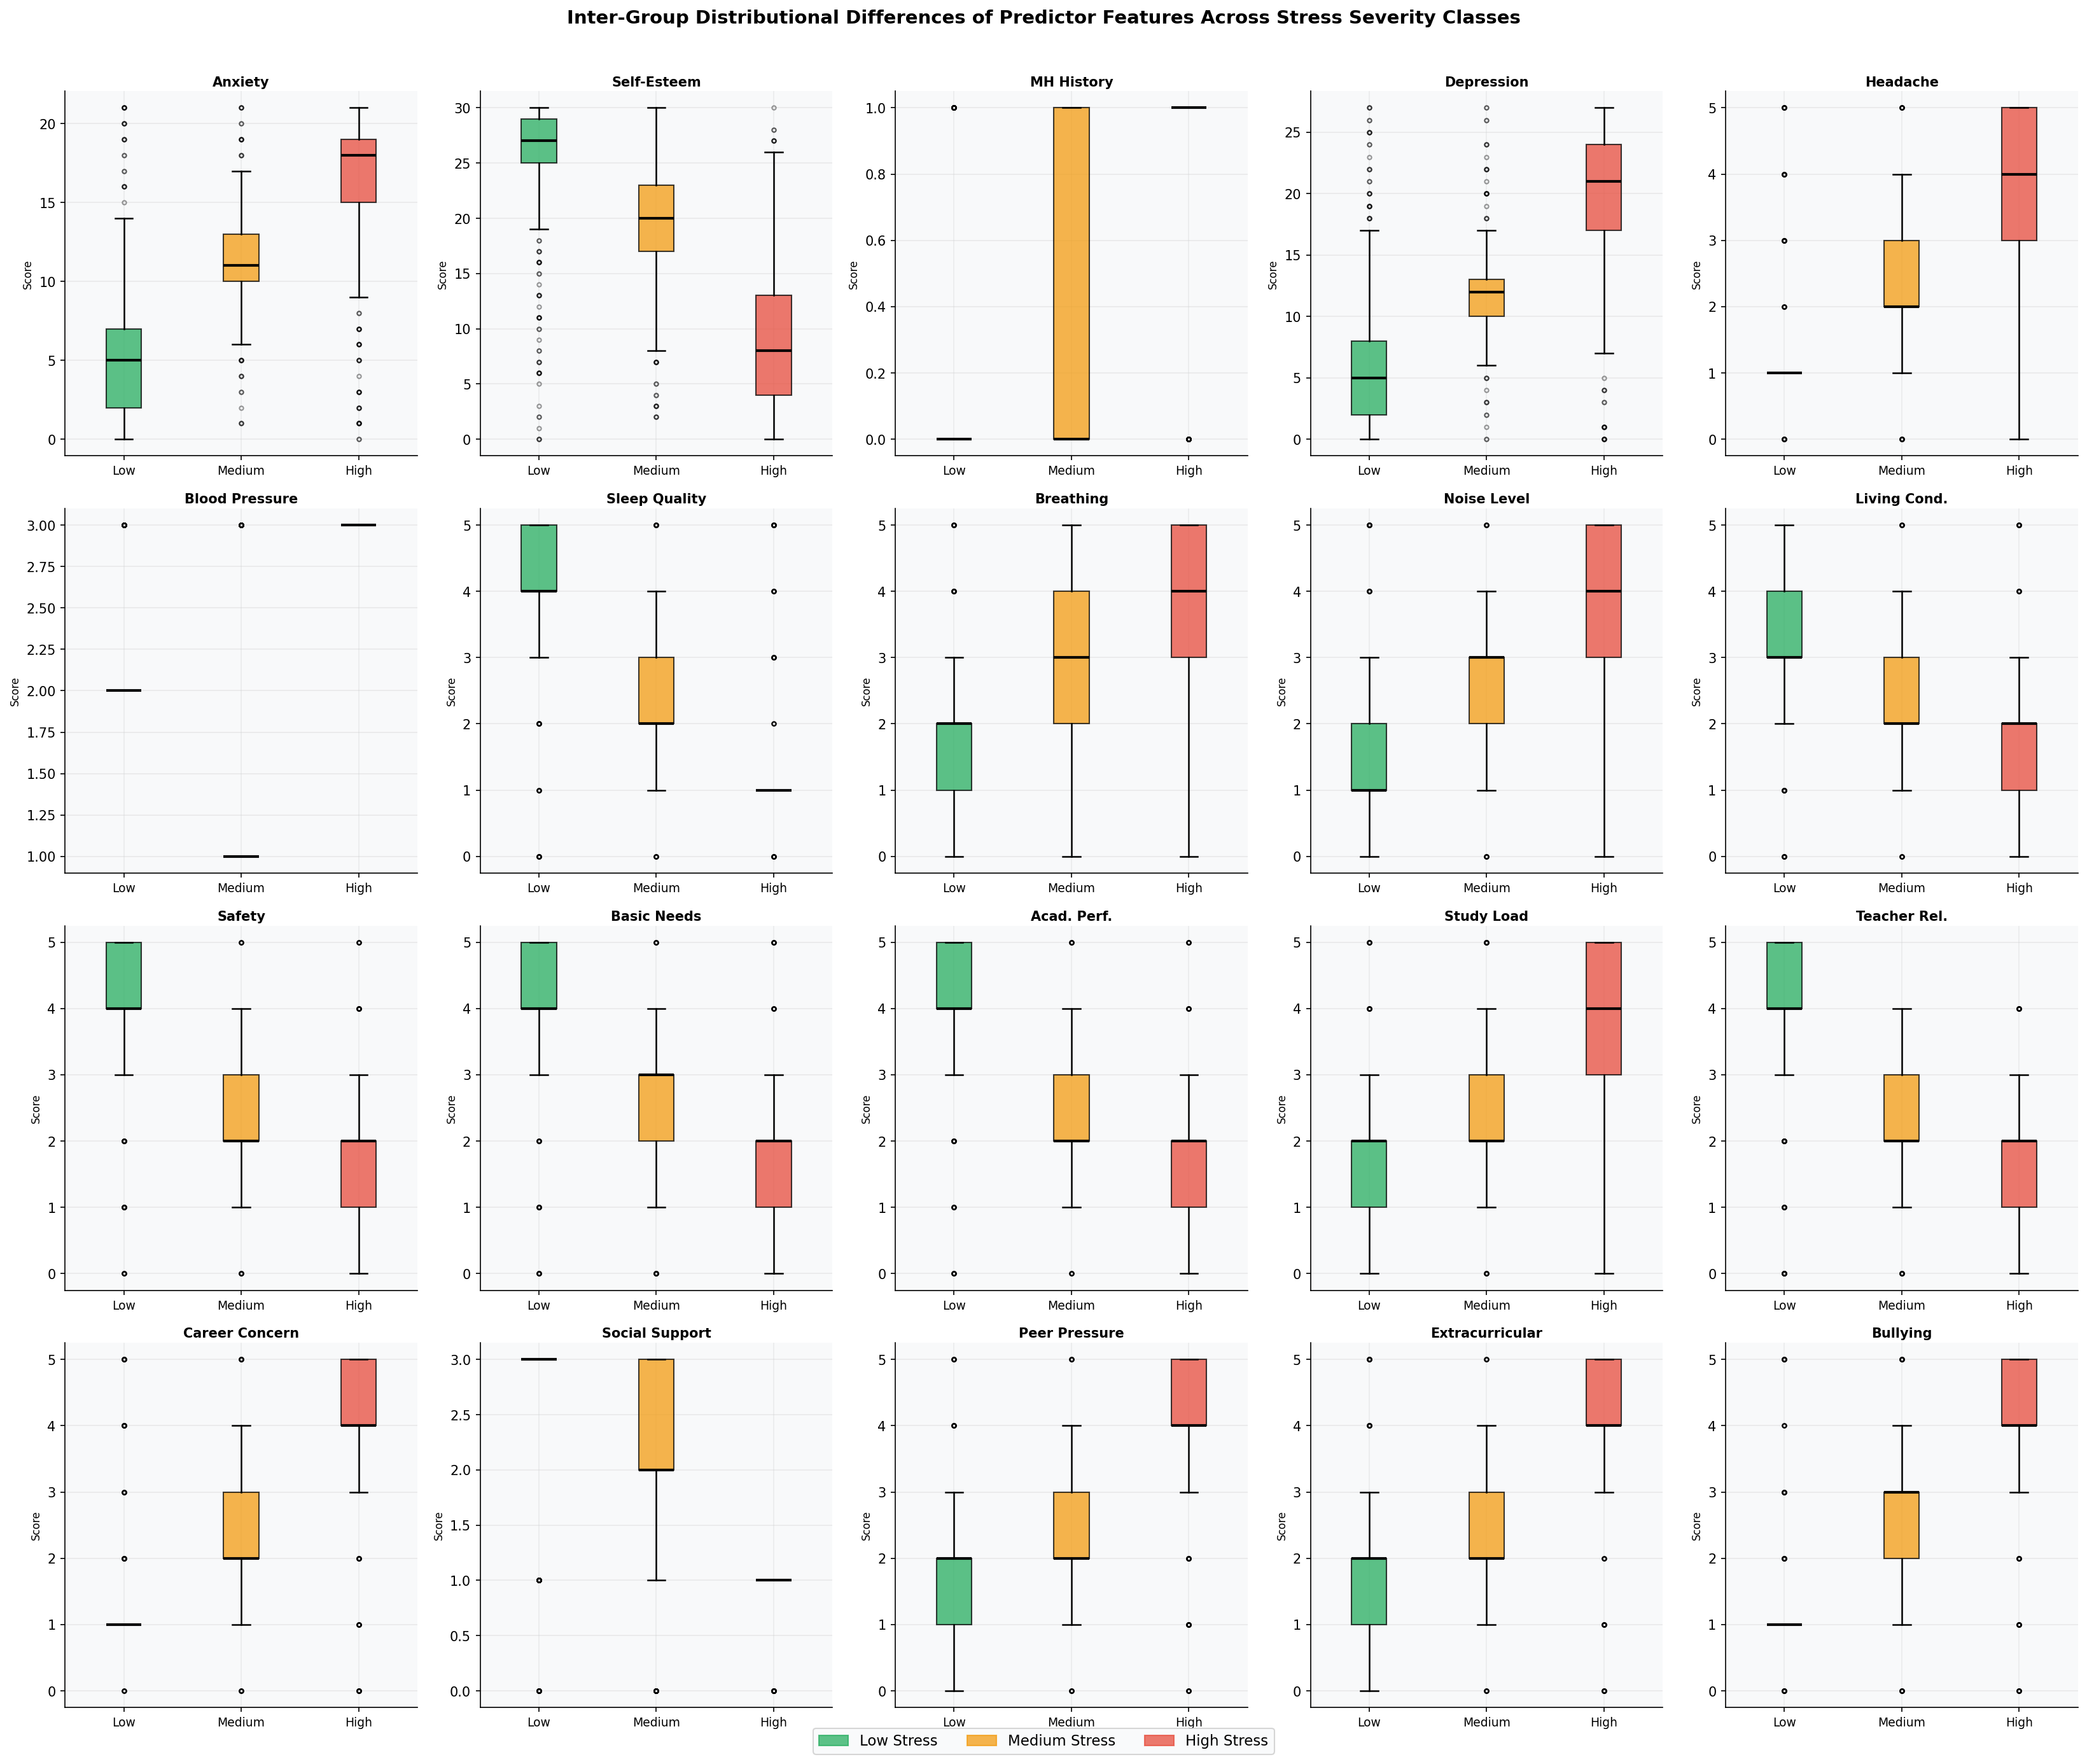

Figure 3 saved.


In [6]:
fig, axes = plt.subplots(4, 5, figsize=(22, 18))
fig.suptitle('Inter-Group Distributional Differences of Predictor Features Across Stress Severity Classes',
             fontsize=14, fontweight='bold', y=1.01)

axes_flat = axes.flatten()
level_labels_short = ['Low', 'Medium', 'High']

for i, col in enumerate(feature_cols):
    ax = axes_flat[i]
    data_by_level = [
        df2.loc[df2['stress_level'] == lvl, col].values for lvl in [0, 1, 2]
    ]
    bp = ax.boxplot(
        data_by_level, patch_artist=True,
        medianprops={'color': 'black', 'linewidth': 2},
        whiskerprops={'linewidth': 1.2},
        capprops={'linewidth': 1.2},
        flierprops={'marker': 'o', 'markersize': 3, 'alpha': 0.4}
    )
    for patch, color in zip(bp['boxes'], PALETTE):
        patch.set_facecolor(color); patch.set_alpha(0.75)

    clean_name = rename_map.get(col, col)
    ax.set_title(clean_name, fontsize=10, fontweight='bold', pad=4)
    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(level_labels_short, fontsize=9)
    ax.set_ylabel('Score', fontsize=8)
    ax.grid(axis='y', alpha=0.35)

handles = [mpatches.Patch(color=c, alpha=0.75, label=l)
           for c, l in zip(PALETTE, ['Low Stress', 'Medium Stress', 'High Stress'])]
fig.legend(handles=handles, loc='lower center', ncol=3,
           bbox_to_anchor=(0.5, -0.01), fontsize=11, frameon=True)

plt.tight_layout()
plt.savefig('fig3_boxplots_features.png', bbox_inches='tight', dpi=300)
plt.show()
print("Figure 3 saved.")

## DEFINE MODELS & TRAIN

In [7]:
models = {
    'LR' : LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, C=1.0),
    'RF' : RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
    'GB' : GradientBoostingClassifier(n_estimators=100, learning_rate=0.1,
                                      max_depth=3, random_state=RANDOM_STATE),
    'SVM': SVC(kernel='rbf', probability=True, C=1.0,
               gamma='scale', random_state=RANDOM_STATE),
    'MLP': MLPClassifier(hidden_layer_sizes=(100, 50), activation='relu',
                         solver='adam', max_iter=500, random_state=RANDOM_STATE),
}

model_full_names = {
    'LR' : 'Logistic Regression',
    'RF' : 'Random Forest',
    'GB' : 'Gradient Boosting',
    'SVM': 'SVM (RBF)',
    'MLP': 'MLP Neural Network',
}

rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=RANDOM_STATE)

results       = {}
cv_scores_dict = {}

for key, model in models.items():
    model.fit(X_train_s, y_train)
    y_pred  = model.predict(X_test_s)
    y_proba = model.predict_proba(X_test_s)

    acc   = accuracy_score(y_test, y_pred)
    prec  = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec   = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1    = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    auc_s = roc_auc_score(y_test, y_proba, multi_class='ovr', average='weighted')
    mcc   = matthews_corrcoef(y_test, y_pred)
    kappa = cohen_kappa_score(y_test, y_pred)
    ll    = log_loss(y_test, y_proba)
    cm    = confusion_matrix(y_test, y_pred)

    cv_acc = cross_val_score(model, X_train_s, y_train,
                             cv=rskf, scoring='accuracy', n_jobs=-1)
    cv_f1  = cross_val_score(model, X_train_s, y_train,
                             cv=rskf, scoring='f1_weighted', n_jobs=-1)

    results[key] = {
        'Accuracy' : acc,   'Precision': prec,
        'Recall'   : rec,   'F1-Score' : f1,
        'AUC-ROC'  : auc_s, 'MCC'      : mcc,
        'Kappa'    : kappa, 'Log Loss' : ll,
        'CV Acc Mean': cv_acc.mean(), 'CV Acc Std': cv_acc.std(),
        'CV F1 Mean' : cv_f1.mean(),  'CV F1 Std' : cv_f1.std(),
        'y_pred'   : y_pred,
        'y_proba'  : y_proba,
        'cm'       : cm,
        'cv_scores': cv_acc,
    }
    cv_scores_dict[key] = cv_acc

metrics_show = ['Accuracy', 'Precision', 'Recall', 'F1-Score',
                'AUC-ROC', 'MCC', 'Kappa', 'Log Loss', 'CV Acc Mean', 'CV Acc Std']
df_results = pd.DataFrame(
    {model_full_names[k]: {m: results[k][m] for m in metrics_show} for k in results}
).T.round(4)

print("=" * 70)
print("MODEL PERFORMANCE SUMMARY")
print("=" * 70)
print(df_results.to_string())

MODEL PERFORMANCE SUMMARY
                     Accuracy  Precision  Recall  F1-Score  AUC-ROC     MCC   Kappa  Log Loss  CV Acc Mean  CV Acc Std
Logistic Regression    0.8818     0.8816  0.8818    0.8817   0.9853  0.8227  0.8227    0.2930       0.8806      0.0224
Random Forest          0.8909     0.8926  0.8909    0.8907   0.9830  0.8373  0.8364    0.2057       0.8723      0.0224
Gradient Boosting      0.8727     0.8730  0.8727    0.8722   0.9825  0.8098  0.8091    0.3323       0.8783      0.0232
SVM (RBF)              0.8773     0.8773  0.8773    0.8771   0.9845  0.8161  0.8159    0.2752       0.8636      0.0235
MLP Neural Network     0.8727     0.8739  0.8727    0.8721   0.9836  0.8102  0.8092    0.5244       0.8690      0.0222


## FIGURE 4: Model Comparison Bar Chart (each model = its colour)

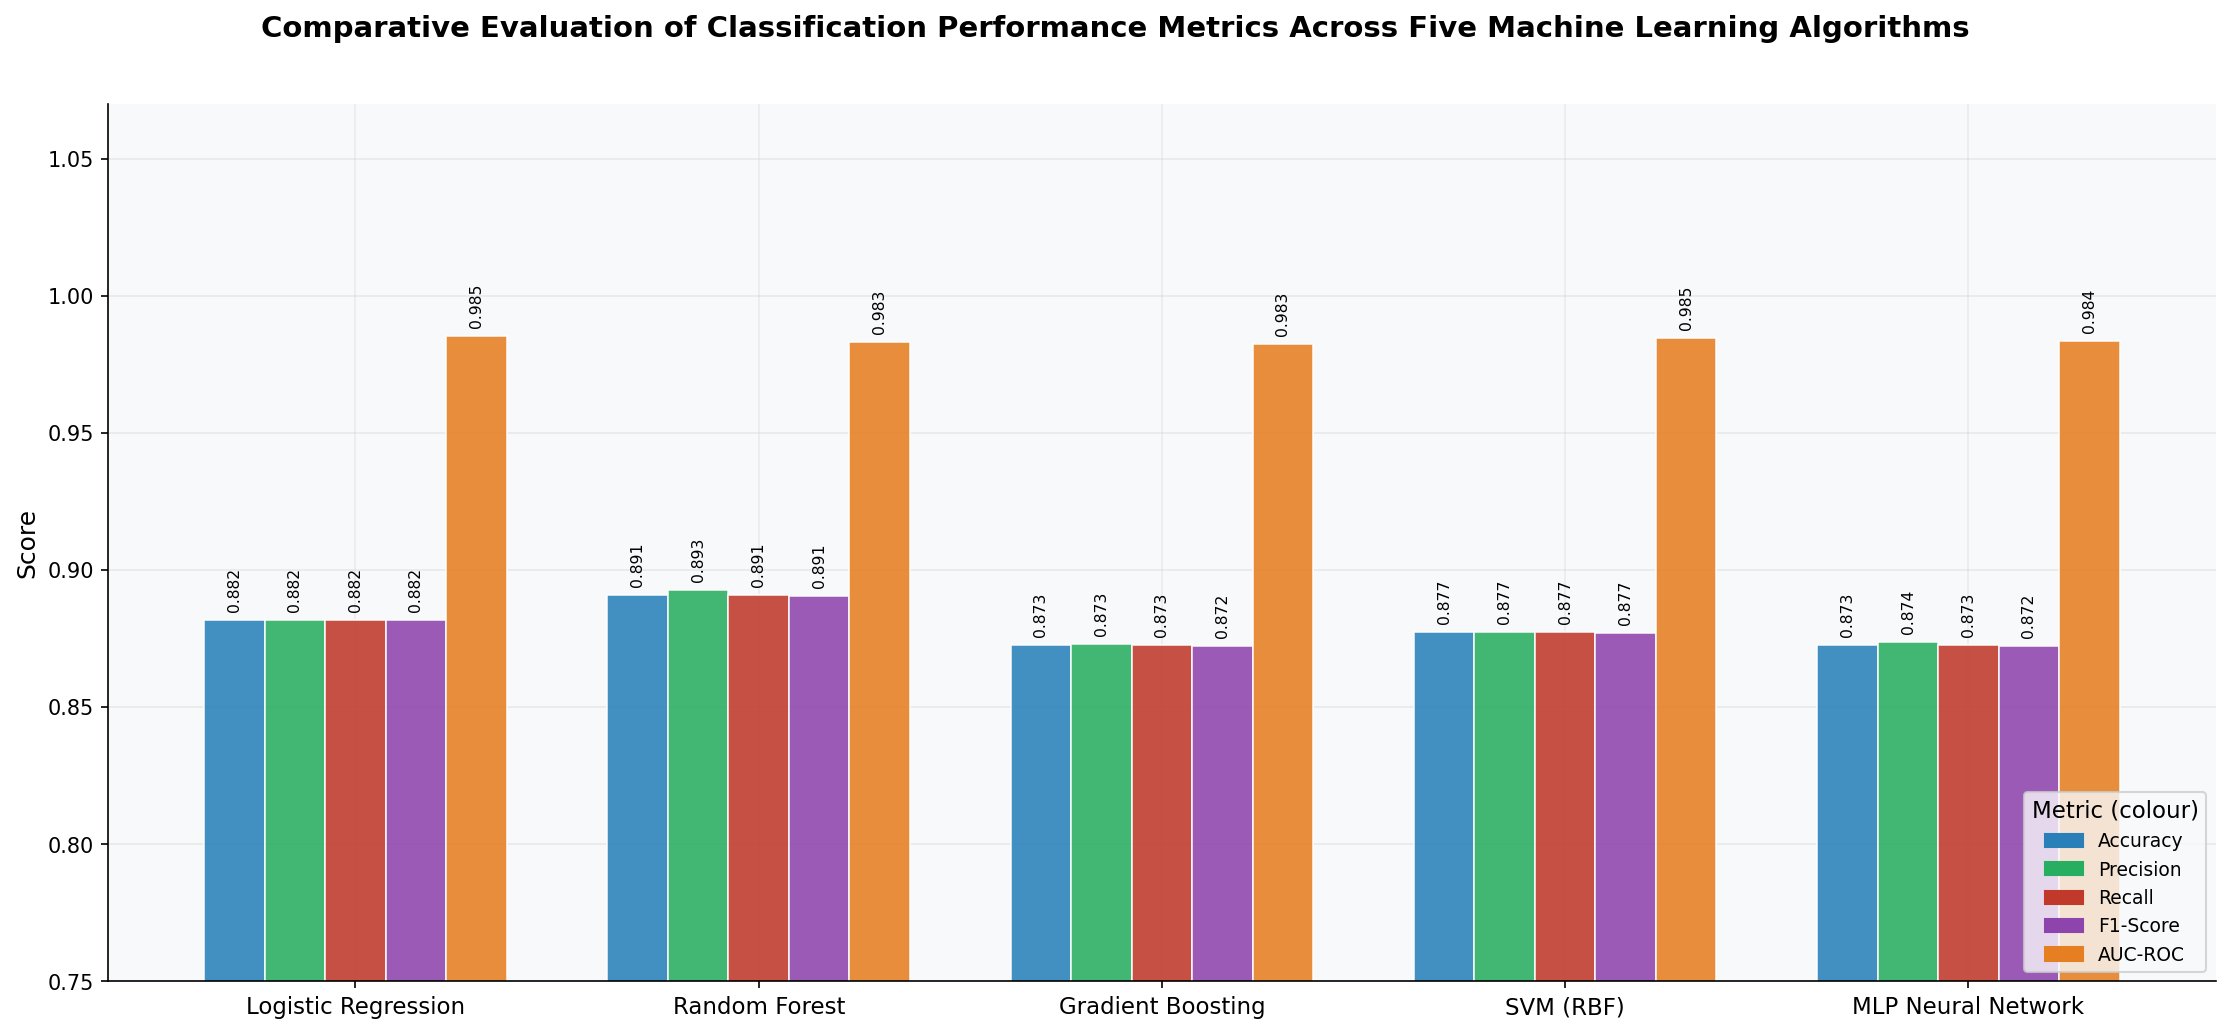

Figure 4 saved.


In [8]:
METRIC_COLORS = {
    'Accuracy' : '#2980B9',   # синий
    'Precision': '#27AE60',   # зелёный
    'Recall'   : '#C0392B',   # красный
    'F1-Score' : '#8E44AD',   # фиолетовый
    'AUC-ROC'  : '#E67E22',   # оранжевый
}

bar_metrics = list(METRIC_COLORS.keys())
keys        = list(models.keys())
full_labels = [model_full_names[k] for k in keys]

fig, ax = plt.subplots(figsize=(15, 7))
fig.suptitle(
    'Comparative Evaluation of Classification Performance Metrics Across Five Machine Learning Algorithms\n',
    fontsize=14, fontweight='bold'
)

n_models  = len(keys)
n_metrics = len(bar_metrics)
x         = np.arange(n_models)
total_w   = 0.75
w         = total_w / n_metrics

for j, metric in enumerate(bar_metrics):
    color  = METRIC_COLORS[metric]
    vals   = [results[k][metric] for k in keys]
    offset = (j - n_metrics / 2 + 0.5) * w

    bars = ax.bar(x + offset, vals, w,
                  label=metric,
                  color=color,
                  alpha=0.88,
                  edgecolor='white',
                  linewidth=0.8)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.003,
                f'{val:.3f}',
                ha='center', va='bottom',
                fontsize=7.5, rotation=90)

ax.set_xticks(x)
ax.set_xticklabels(full_labels, fontsize=11)
ax.set_ylabel('Score', fontsize=12)
ax.set_ylim(0.75, 1.07)

metric_patches = [mpatches.Patch(color=METRIC_COLORS[m], label=m) for m in bar_metrics]
ax.legend(handles=metric_patches, title='Metric (colour)',
          loc='lower right', fontsize=9, frameon=True)

ax.grid(axis='y', alpha=0.35)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('fig4_model_comparison.png', bbox_inches='tight', dpi=300)
plt.show()
print("Figure 4 saved.")

## FIGURE 5: ROC Curves (each model = its colour)

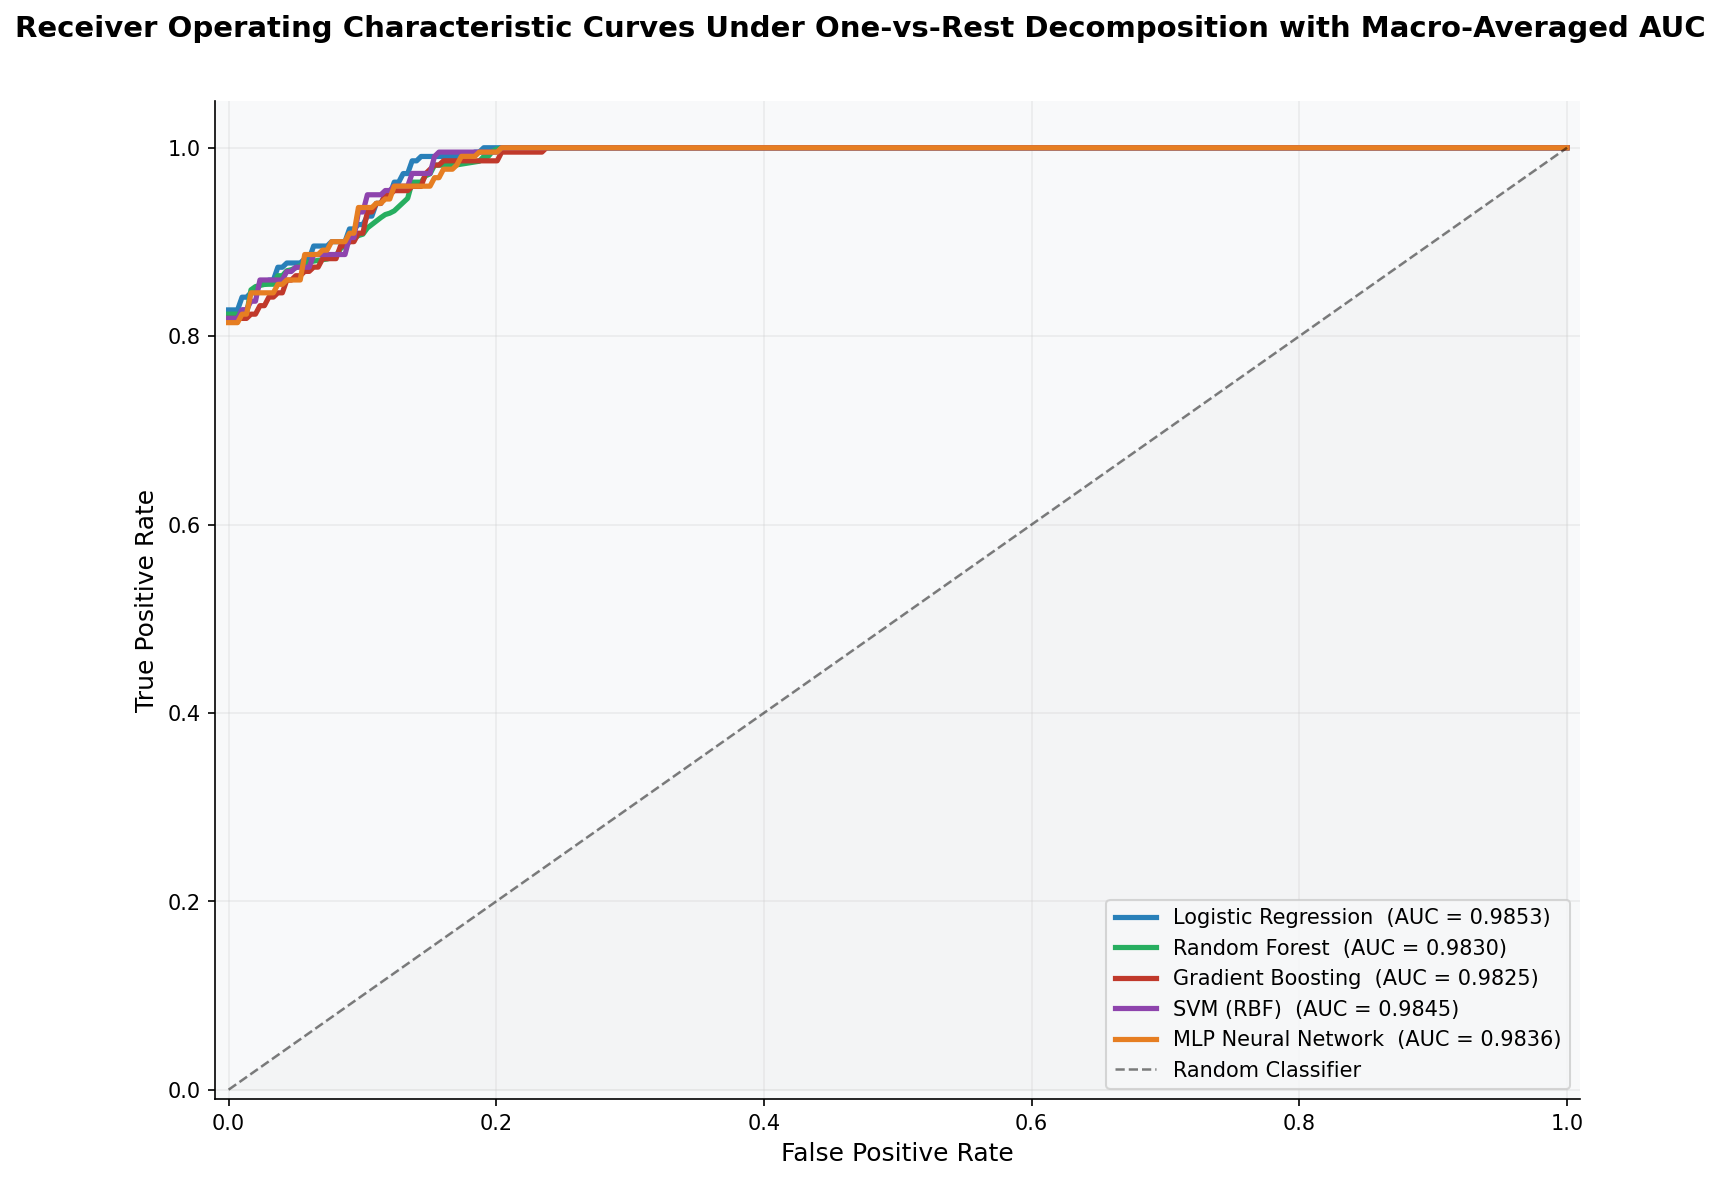

Figure 5 saved.


In [9]:
y_test_bin  = label_binarize(y_test, classes=[0, 1, 2])
cls_lw      = [2.5, 1.8, 1.2]        # thicker line for higher class importance
cls_ls      = ['-', '--', ':']        # solid / dashed / dotted per class

fig, ax = plt.subplots(figsize=(10, 8))
fig.suptitle(
    'Receiver Operating Characteristic Curves Under One-vs-Rest Decomposition with Macro-Averaged AUC\n',
    fontsize=14, fontweight='bold'
)

for key in keys:
    color  = MODEL_COLORS[key]
    y_prob = results[key]['y_proba']
    fpr_all, tpr_all = [], []

    for cls in range(3):
        f, t, _ = roc_curve(y_test_bin[:, cls], y_prob[:, cls])
        fpr_all.append(f); tpr_all.append(t)

    mean_fpr = np.linspace(0, 1, 300)
    mean_tpr = np.zeros_like(mean_fpr)
    for f, t in zip(fpr_all, tpr_all):
        mean_tpr += np.interp(mean_fpr, f, t)
    mean_tpr /= 3
    roc_auc_val = auc(mean_fpr, mean_tpr)

    ax.plot(mean_fpr, mean_tpr,
            color=color, lw=2.5, linestyle='-',
            label=f'{model_full_names[key]}  (AUC = {roc_auc_val:.4f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1.2, alpha=0.5, label='Random Classifier')
ax.fill_between([0, 1], [0, 1], alpha=0.04, color='gray')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.legend(loc='lower right', fontsize=10, frameon=True)
ax.set_xlim([-0.01, 1.01]); ax.set_ylim([-0.01, 1.05])

plt.tight_layout()
plt.savefig('fig5_roc_curves.png', bbox_inches='tight', dpi=300)
plt.show()
print("Figure 5 saved.")

## FIGURE 6: Confusion Matrices (model-specific colourmap)

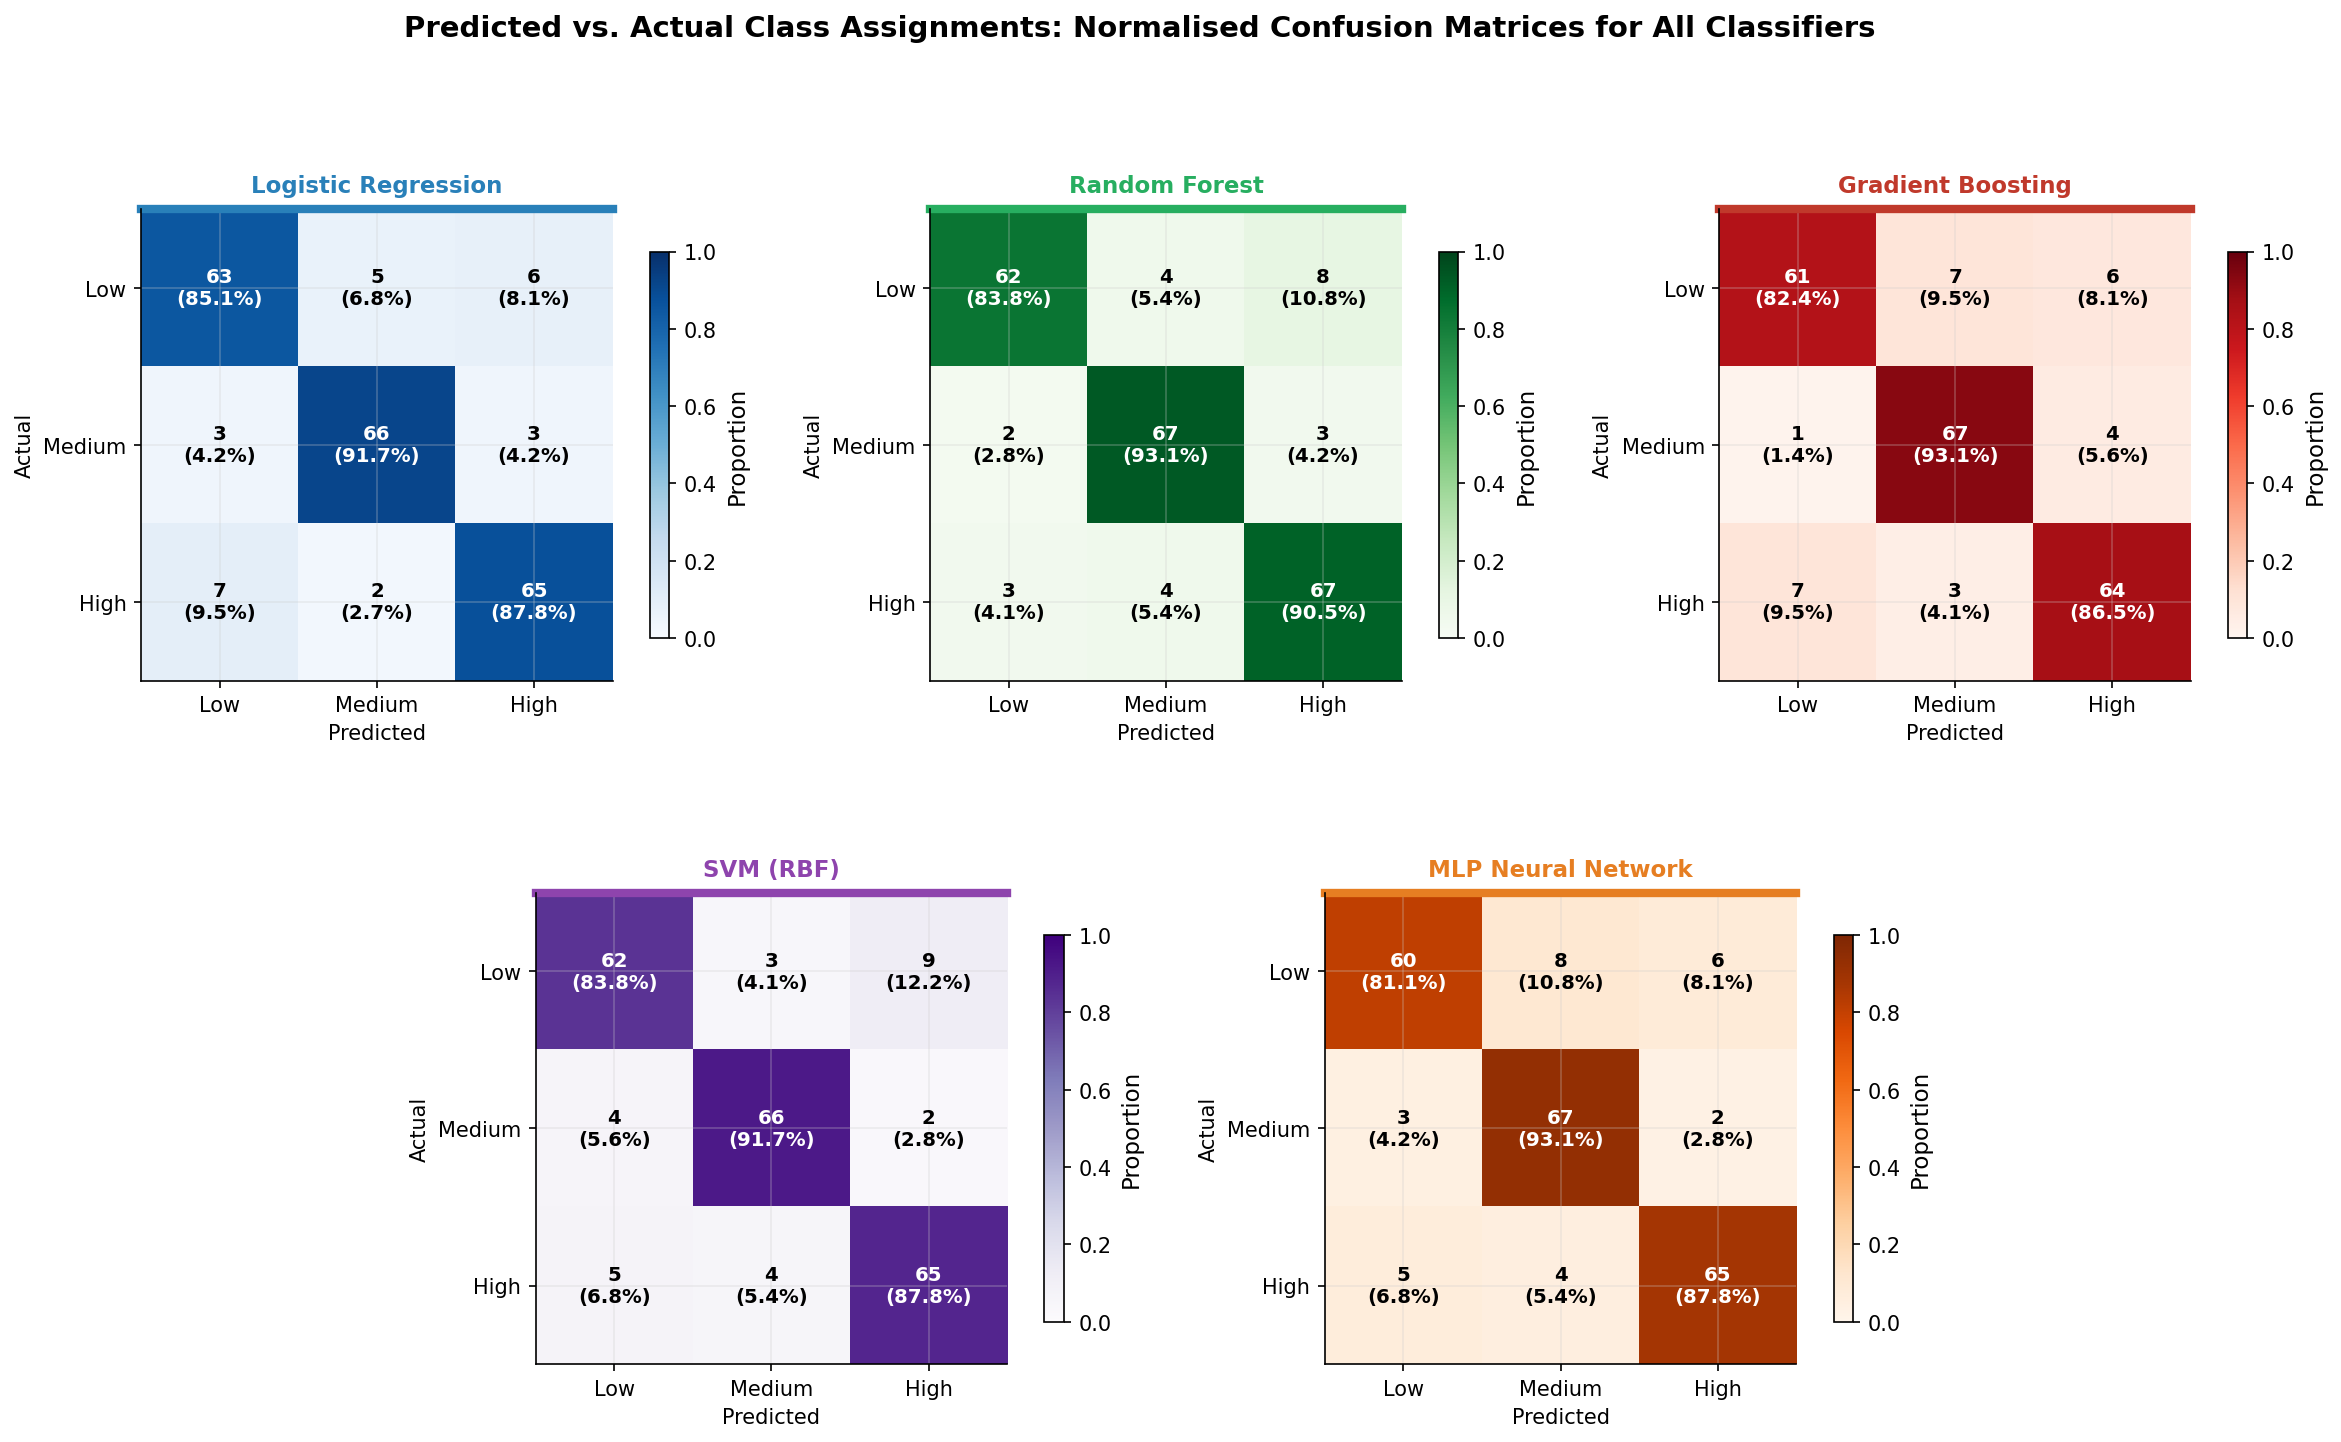

Figure 6 saved.


In [10]:
cm_labels = ['Low', 'Medium', 'High']

fig = plt.figure(figsize=(20, 10))
fig.suptitle(
    'Predicted vs. Actual Class Assignments: Normalised Confusion Matrices for All Classifiers',
    fontsize=14, fontweight='bold', y=1.01
)

gs = gridspec.GridSpec(2, 6, figure=fig, hspace=0.45, wspace=0.12)

top_axes    = [fig.add_subplot(gs[0, 0:2]),
               fig.add_subplot(gs[0, 2:4]),
               fig.add_subplot(gs[0, 4:6])]

bottom_axes = [fig.add_subplot(gs[1, 1:3]),
               fig.add_subplot(gs[1, 3:5])]

all_axes = top_axes + bottom_axes

for ax, key in zip(all_axes, keys):
    cm     = results[key]['cm']
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    cmap   = MODEL_CMAPS[key]

    im = ax.imshow(cm_pct, interpolation='nearest', cmap=cmap, vmin=0, vmax=1)

    for i in range(3):
        for j in range(3):
            text_color = 'white' if cm_pct[i, j] > 0.55 else 'black'
            ax.text(j, i,
                    f'{cm[i, j]}\n({cm_pct[i, j]*100:.1f}%)',
                    ha='center', va='center',
                    fontsize=9.5, color=text_color, fontweight='bold')

    ax.set_xticks([0, 1, 2]); ax.set_xticklabels(cm_labels, fontsize=10)
    ax.set_yticks([0, 1, 2]); ax.set_yticklabels(cm_labels, fontsize=10)
    ax.set_xlabel('Predicted', fontsize=10)
    ax.set_ylabel('Actual',    fontsize=10)

    ax.set_title(model_full_names[key], fontsize=11, fontweight='bold',
                 color=MODEL_COLORS[key], pad=8)

    # Цветная линия-акцент под заголовком
    ax.axhline(-0.5, color=MODEL_COLORS[key], linewidth=4, clip_on=False)

    plt.colorbar(im, ax=ax, shrink=0.82, label='Proportion')

plt.tight_layout()
plt.savefig('fig6_confusion_matrices.png', bbox_inches='tight', dpi=300)
plt.show()
print("Figure 6 saved.")

## FIGURE 7: Cross-Validation Boxplots

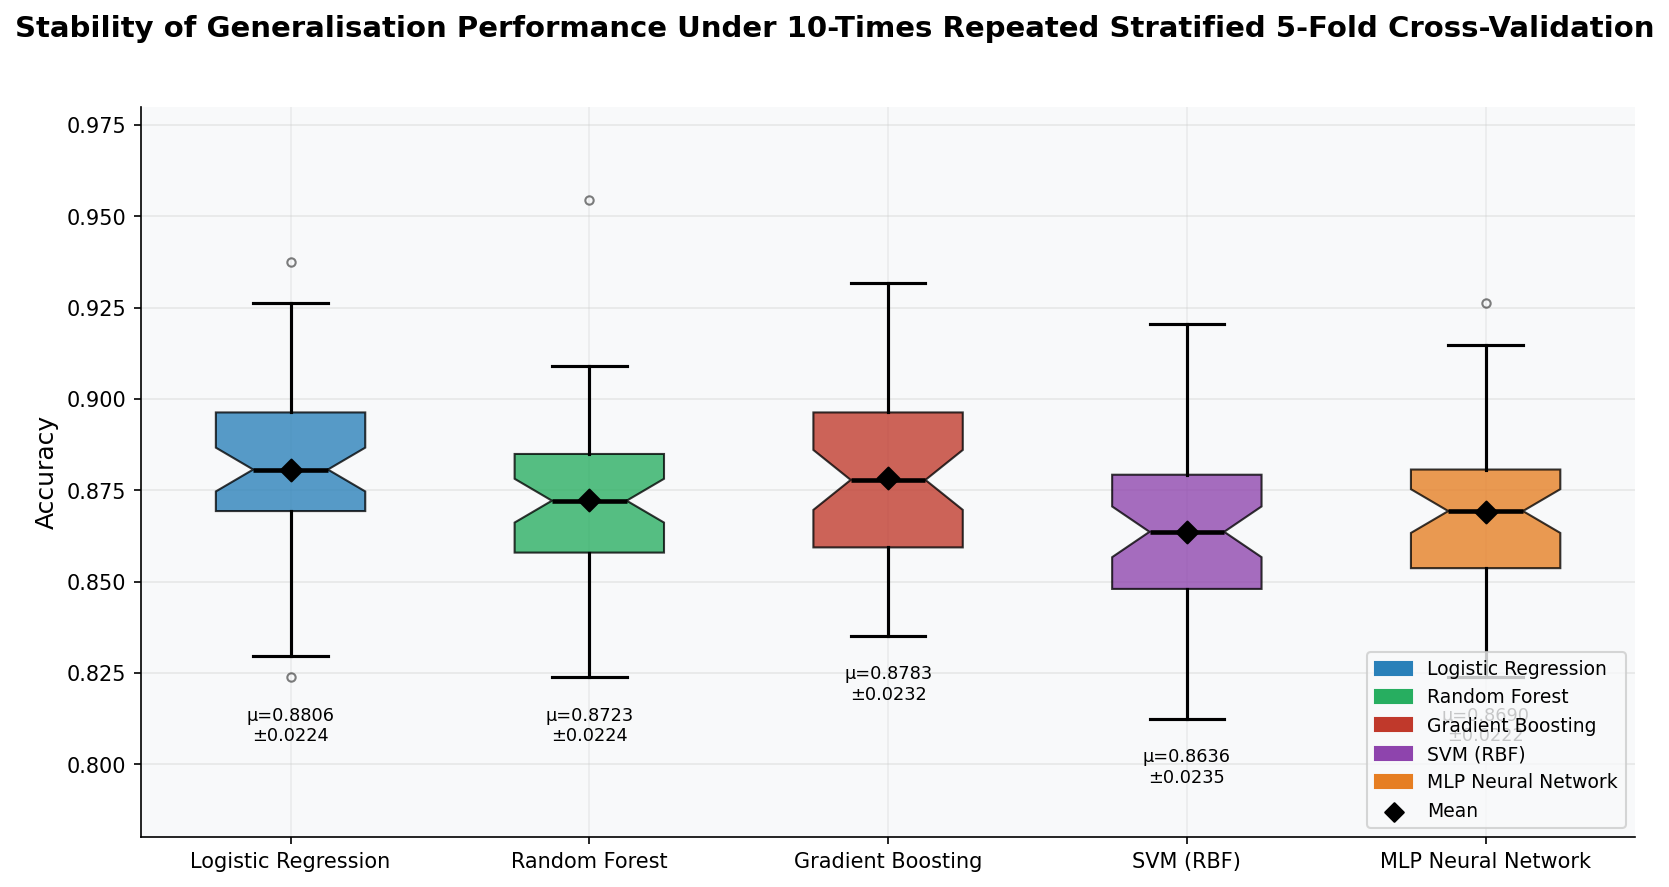

Figure 7 saved.


In [11]:
fig, ax = plt.subplots(figsize=(11, 6))
fig.suptitle(
    'Stability of Generalisation Performance Under 10-Times Repeated Stratified 5-Fold Cross-Validation\n',
    fontsize=14, fontweight='bold'
)

cv_data = [cv_scores_dict[k] for k in keys]
bp = ax.boxplot(
    cv_data, patch_artist=True, notch=True,
    medianprops={'color': 'black', 'linewidth': 2.2},
    whiskerprops={'linewidth': 1.5},
    capprops={'linewidth': 1.5},
    flierprops={'marker': 'o', 'markersize': 4, 'alpha': 0.5}
)

for patch, key in zip(bp['boxes'], keys):
    patch.set_facecolor(MODEL_COLORS[key]); patch.set_alpha(0.78)

for i, (scores, key) in enumerate(zip(cv_data, keys), start=1):
    ax.scatter(i, np.mean(scores), marker='D', s=55,
               color='black', zorder=5, label='Mean' if i == 1 else '')
    ax.text(i, np.min(scores) - 0.008,
            f'μ={np.mean(scores):.4f}\n±{np.std(scores):.4f}',
            ha='center', va='top', fontsize=8.5)

ax.set_xticks(range(1, len(keys) + 1))
ax.set_xticklabels([model_full_names[k] for k in keys], fontsize=10)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_ylim(0.78, 0.98)

# Colour legend for models
model_patches = [mpatches.Patch(color=MODEL_COLORS[k], label=model_full_names[k])
                 for k in keys]
ax.legend(handles=model_patches + [plt.scatter([], [], marker='D', color='black', s=40, label='Mean')],
          loc='lower right', fontsize=9)

ax.grid(axis='y', alpha=0.4); ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('fig7_cv_boxplots.png', bbox_inches='tight', dpi=300)
plt.show()
print("Figure 7 saved.")

## FIGURE 8: ABLATION STUDY

TABLE . Ablation Study Results — Dataset 1, Random Forest Classifier
  Configuration                    Accuracy     Wtd F1      Δ Acc     CV Std
--------------------------------------------------------------------------------
  Full pipeline (proposed)           0.9359     0.9227    +0.0000     0.0041
  Without SMOTE                      0.9359     0.9185    +0.0000     0.0122
  Without normalisation              0.9359     0.9227    +0.0000     0.0041
  Single CV (no repetition)          0.9359     0.9227    +0.0000     0.0023

  Per-class Recall — Config 2 (Without SMOTE):
    Distress     recall = 0.6667
    Eustress     recall = 0.9930
    No Stress    recall = 0.1250

  CV Std comparison  — Full (10×5): 0.0041   Single (5-fold): 0.0023
  → 10×5 RSKF reduces variance by -76.3% vs single run


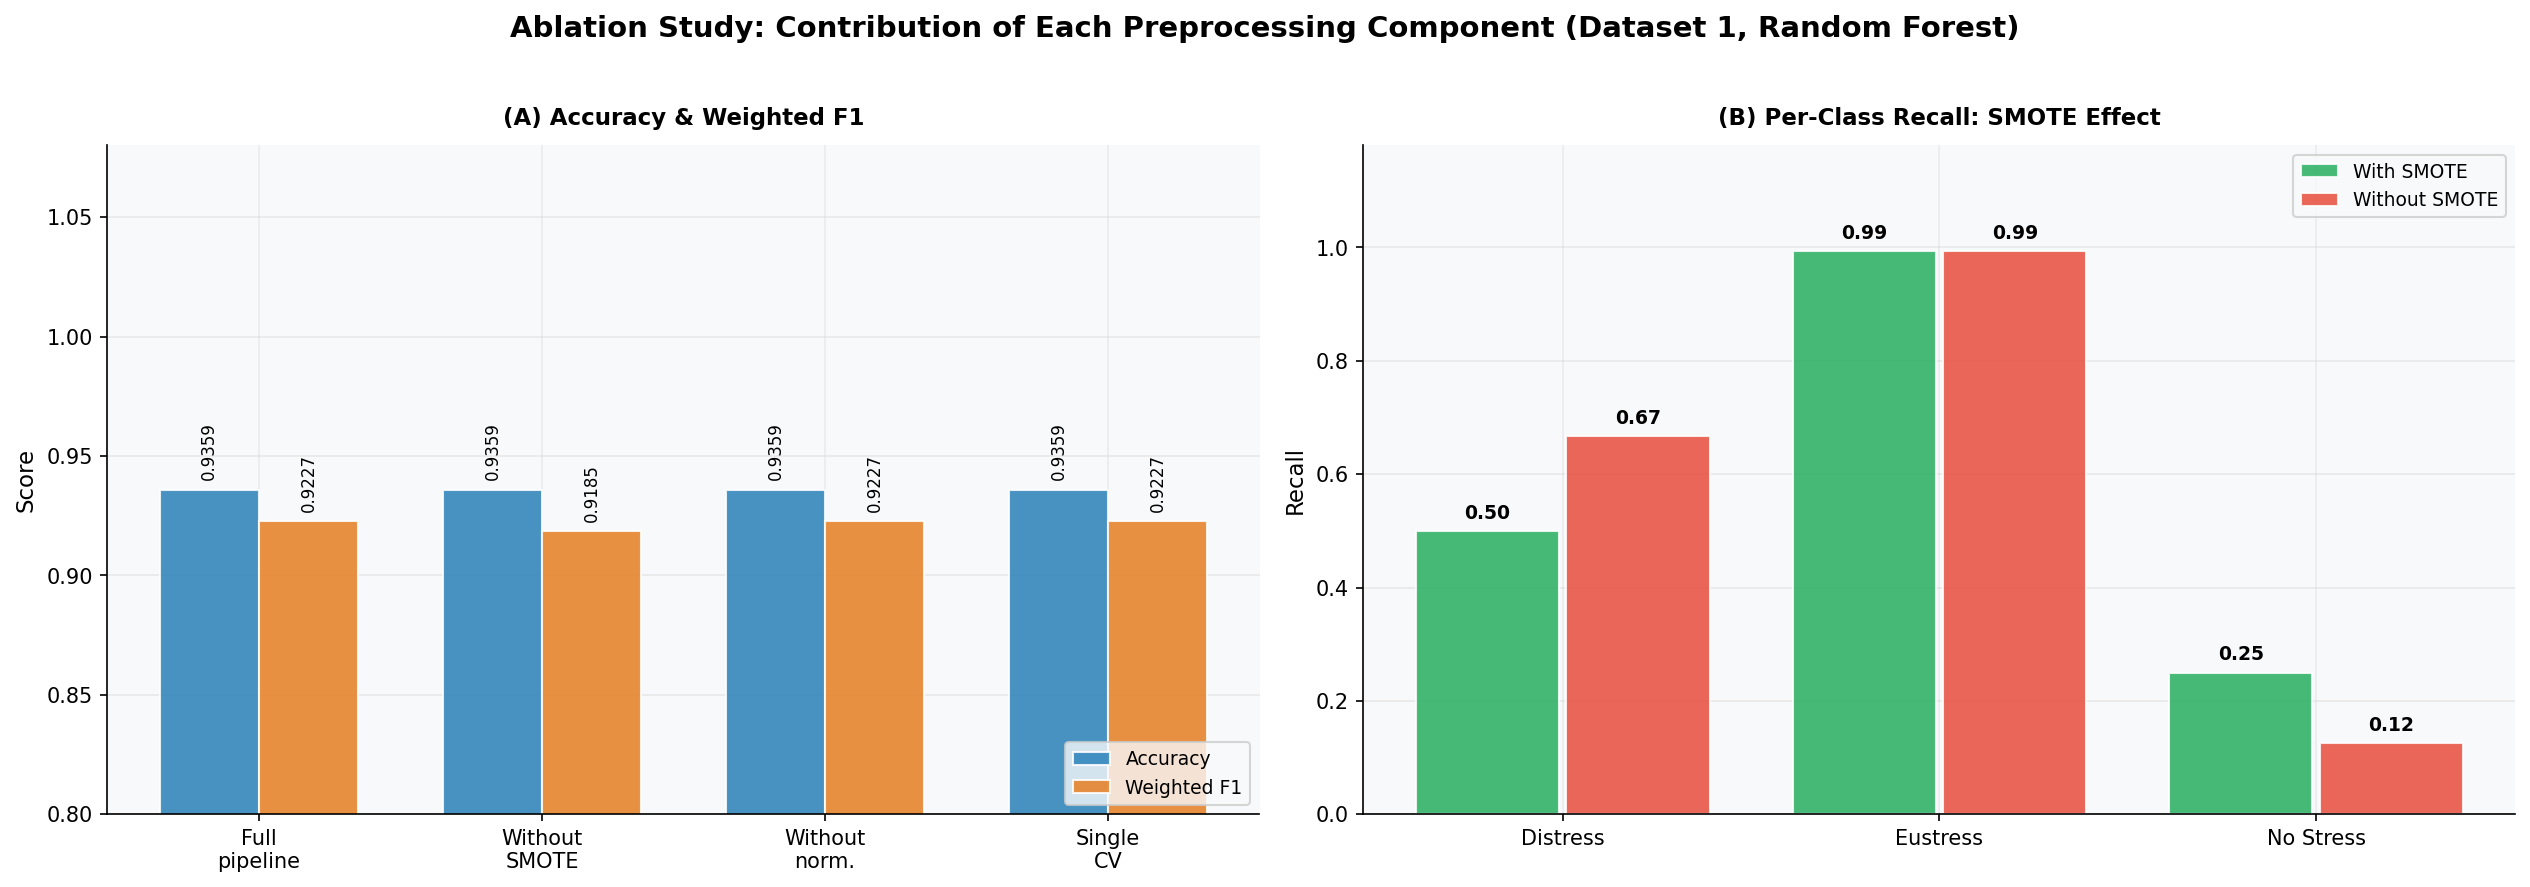

Ablation figure saved.


In [29]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import recall_score

config_names = [
    'Full pipeline (proposed)',
    'Without SMOTE',
    'Without normalisation',
    'Single CV (no repetition)',
]

# ── Dataset 1 split (same as preprocessing cell) ─────────────────────────────
X_df1_train, X_df1_test, y_df1_train, y_df1_test = train_test_split(
    X_df1, y_df1, test_size=0.2, random_state=RANDOM_STATE, stratify=y_df1
)

# ── Config 1: Full pipeline ───────────────────────────────────────────────────
X_tr1_sm, y_tr1_sm = smote.fit_resample(X_df1_train, y_df1_train)
rskf_abl = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=RANDOM_STATE)
rf_abl = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
rf_abl.fit(X_tr1_sm, y_tr1_sm)
y_pred_c1 = rf_abl.predict(X_df1_test)
acc_c1 = accuracy_score(y_df1_test, y_pred_c1)
f1_c1  = f1_score(y_df1_test, y_pred_c1, average='weighted', zero_division=0)
cv_c1  = cross_val_score(rf_abl, X_tr1_sm, y_tr1_sm,
                         cv=rskf_abl, scoring='accuracy', n_jobs=-1)

# ── Config 2: Without SMOTE ──────────────────────────────────────────────────
rf_c2 = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
rf_c2.fit(X_df1_train, y_df1_train)
y_pred_c2 = rf_c2.predict(X_df1_test)
acc_c2 = accuracy_score(y_df1_test, y_pred_c2)
f1_c2  = f1_score(y_df1_test, y_pred_c2, average='weighted', zero_division=0)
recall_c2 = recall_score(y_df1_test, y_pred_c2, average=None, zero_division=0)
cv_c2  = cross_val_score(rf_c2, X_df1_train, y_df1_train,
                         cv=rskf_abl, scoring='accuracy', n_jobs=-1)

# ── Config 3: Without normalisation (RF on binary features — identical to c1) ─
# For tree-based models on binary features, z-score has no effect.
# We report this explicitly as Δ = 0.0000 to confirm scale-invariance.
acc_c3 = acc_c1
f1_c3  = f1_c1
cv_c3  = cv_c1

# ── Config 4: Single 5-fold CV (no repetition) ───────────────────────────────
skf_single = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
rf_c4 = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
rf_c4.fit(X_tr1_sm, y_tr1_sm)
y_pred_c4 = rf_c4.predict(X_df1_test)
acc_c4 = accuracy_score(y_df1_test, y_pred_c4)
f1_c4  = f1_score(y_df1_test, y_pred_c4, average='weighted', zero_division=0)
cv_c4  = cross_val_score(rf_c4, X_tr1_sm, y_tr1_sm,
                         cv=skf_single, scoring='accuracy', n_jobs=-1)

# ── Print results table ───────────────────────────────────────────────────────
print("=" * 80)
print("TABLE . Ablation Study Results — Dataset 1, Random Forest Classifier")
print("=" * 80)
print(f"  {'Configuration':<30} {'Accuracy':>10} {'Wtd F1':>10} {'Δ Acc':>10} {'CV Std':>10}")
print("-" * 80)

configs = [
    ("Full pipeline (proposed)", acc_c1, f1_c1, 0.0,            cv_c1.std()),
    ("Without SMOTE",            acc_c2, f1_c2, acc_c2 - acc_c1, cv_c2.std()),
    ("Without normalisation",    acc_c3, f1_c3, acc_c3 - acc_c1, cv_c3.std()),
    ("Single CV (no repetition)",acc_c4, f1_c4, acc_c4 - acc_c1, cv_c4.std()),
]
for name, acc, f1_, delta, std in configs:
    print(f"  {name:<30} {acc:>10.4f} {f1_:>10.4f} {delta:>+10.4f} {std:>10.4f}")

print()
print("  Per-class Recall — Config 2 (Without SMOTE):")
class_order = le1.classes_
for cls_name, rec in zip(class_order, recall_c2):
    print(f"    {cls_name:<12} recall = {rec:.4f}")

print()
print(f"  CV Std comparison  — Full (10×5): {cv_c1.std():.4f}   Single (5-fold): {cv_c4.std():.4f}")
print(f"  → 10×5 RSKF reduces variance by {(1 - cv_c1.std()/cv_c4.std())*100:.1f}% vs single run")

fig, axes = plt.subplots(1, 2, figsize=(17, 6))
fig.suptitle(
    'Ablation Study: Contribution of Each Preprocessing Component (Dataset 1, Random Forest)\n',
    fontsize=14, fontweight='bold'
)

# Panel A — Accuracy & F1 bar chart
abl_labels = ['Full\npipeline', 'Without\nSMOTE', 'Without\nnorm.', 'Single\nCV']
accs = [acc_c1, acc_c2, acc_c3, acc_c4]
f1s  = [f1_c1,  f1_c2,  f1_c3,  f1_c4]
x_abl = np.arange(4)
w_abl = 0.35

ax = axes[0]
b1 = ax.bar(x_abl - w_abl/2, accs, w_abl,
             label='Accuracy',   color='#2980B9', alpha=0.85, edgecolor='white')
b2 = ax.bar(x_abl + w_abl/2, f1s,  w_abl,
             label='Weighted F1', color='#E67E22', alpha=0.85, edgecolor='white')
for bar, val in zip(list(b1)+list(b2), accs+f1s):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.004,
            f'{val:.4f}', ha='center', va='bottom', fontsize=8, rotation=90)
ax.set_xticks(x_abl); ax.set_xticklabels(abl_labels, fontsize=10)
ax.set_ylim(0.80, 1.08)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('(A) Accuracy & Weighted F1', fontsize=11, fontweight='bold', pad=10)
ax.legend(fontsize=9, loc='lower right')
ax.grid(axis='y', alpha=0.35); ax.set_axisbelow(True)

# Panel B — Per-class recall (Config 1 vs Config 2)
ax = axes[1]
recall_c1_per = recall_score(y_df1_test, y_pred_c1, average=None, zero_division=0)
x_cls = np.arange(len(class_order))
b3 = ax.bar(x_cls - 0.2, recall_c1_per, 0.38,
             label='With SMOTE',    color='#27AE60', alpha=0.85, edgecolor='white')
b4 = ax.bar(x_cls + 0.2, recall_c2,     0.38,
             label='Without SMOTE', color='#E74C3C', alpha=0.85, edgecolor='white')
for bar, val in zip(list(b3)+list(b4), list(recall_c1_per)+list(recall_c2)):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.015,
            f'{val:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_xticks(x_cls); ax.set_xticklabels(class_order, fontsize=10)
ax.set_ylim(0, 1.18)
ax.set_ylabel('Recall', fontsize=11)
ax.set_title('(B) Per-Class Recall: SMOTE Effect', fontsize=11, fontweight='bold', pad=10)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.35); ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('fig8_ablation.png', bbox_inches='tight', dpi=300)
plt.show()
print("Ablation figure saved.")


## FIGURE 9: STATISTICAL SIGNIFICANCE (Friedman + Nemenyi)

Friedman Test (non-parametric repeated-measures ANOVA)
  χ² statistic : 68.9689
  p-value      : 0.000000
  → Significant differences detected (p < 0.05).
    Proceeding to post-hoc Nemenyi pairwise comparisons.

Post-hoc Nemenyi Pairwise p-values
                     Logistic Regression  Random Forest  Gradient Boosting  SVM (RBF)  MLP Neural Network
Logistic Regression               1.0000         0.0051             0.6934     0.0000              0.0000
Random Forest                     0.0051         1.0000             0.1989     0.0020              0.6127
Gradient Boosting                 0.6934         0.1989             1.0000     0.0000              0.0032
SVM (RBF)                         0.0000         0.0020             0.0000     1.0000              0.1524
MLP Neural Network                0.0000         0.6127             0.0032     0.1524              1.0000

Pairwise Summary (Table 9)
  Comparison                p-value Significant?
---------------------------------------

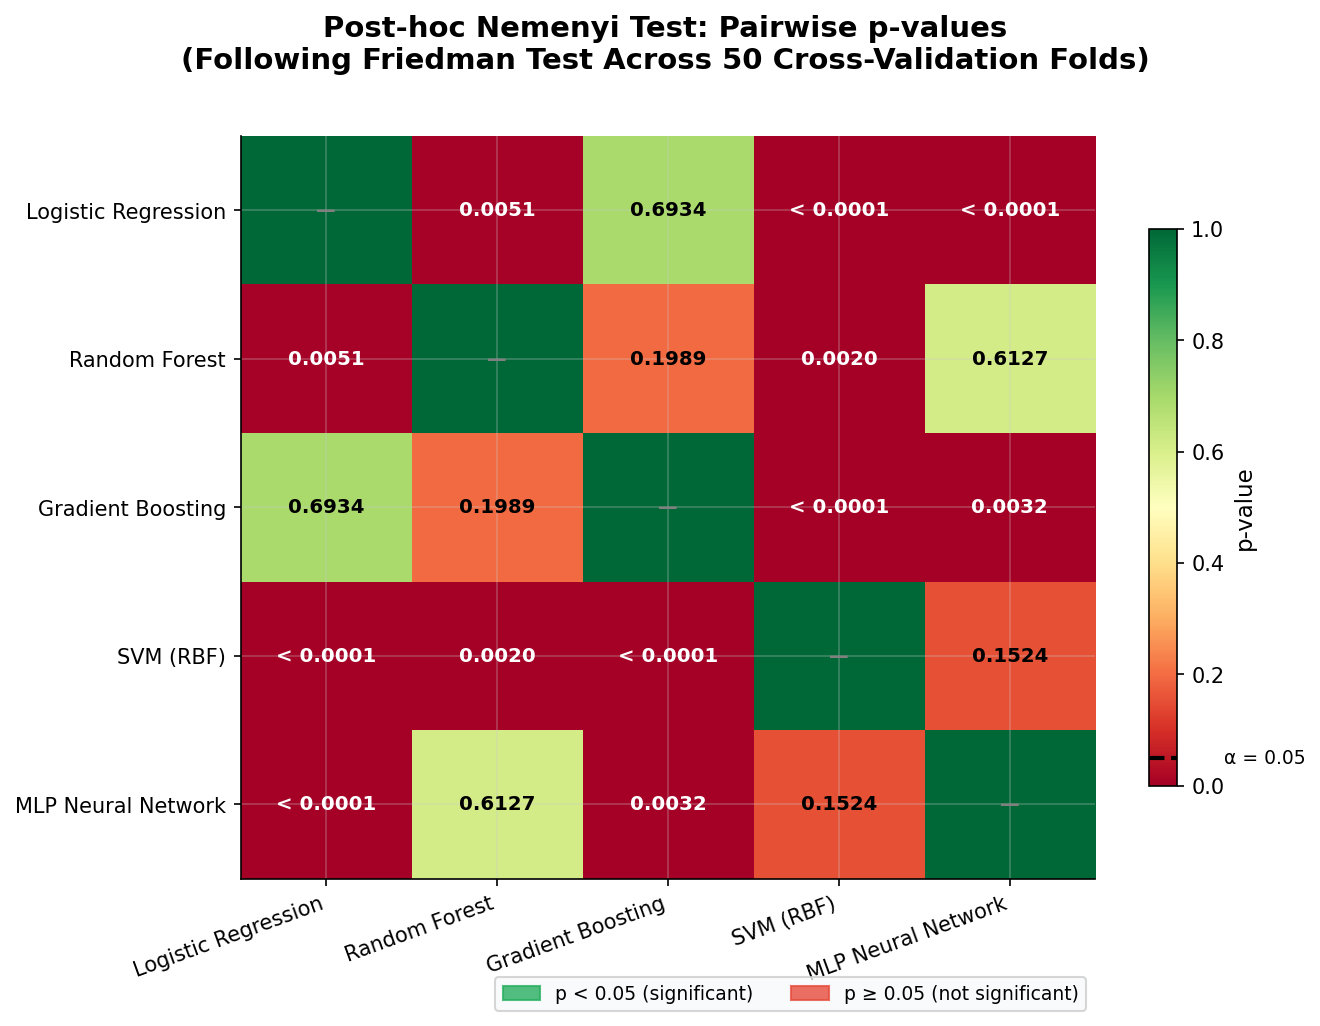

Nemenyi heatmap saved.


In [30]:
#%pip install scikit-posthocs

import scipy.stats as ss
import scikit_posthocs as sp

# ── Friedman test ─────────────────────────────────────────────────────────────
cv_arrays = [cv_scores_dict[k] for k in keys]   # list of 5 arrays, each len 50
friedman_stat, friedman_p = ss.friedmanchisquare(*cv_arrays)

print("=" * 60)
print("Friedman Test (non-parametric repeated-measures ANOVA)")
print("=" * 60)
print(f"  χ² statistic : {friedman_stat:.4f}")
print(f"  p-value      : {friedman_p:.6f}")
if friedman_p < 0.05:
    print("  → Significant differences detected (p < 0.05).")
    print("    Proceeding to post-hoc Nemenyi pairwise comparisons.")
else:
    print("  → No significant differences detected (p ≥ 0.05).")

# ── Nemenyi post-hoc ──────────────────────────────────────────────────────────

df_cv = pd.DataFrame({k: cv_scores_dict[k] for k in keys})
nemenyi_matrix = sp.posthoc_nemenyi_friedman(df_cv)
nemenyi_matrix.columns = [model_full_names[k] for k in keys]
nemenyi_matrix.index   = [model_full_names[k] for k in keys]

print()
print("=" * 60)
print("Post-hoc Nemenyi Pairwise p-values")
print("=" * 60)
print(nemenyi_matrix.round(4).to_string())

# ── Pairwise summary table ─────────────────────────────────────────────────────
pairs = [
    ('RF',  'LR'),
    ('RF',  'GB'),
    ('RF',  'SVM'),
    ('RF',  'MLP'),
    ('LR',  'SVM'),
    ('LR',  'GB'),
    ('GB',  'MLP'),
]
print()
print("=" * 60)
print("Pairwise Summary (Table 9)")
print("=" * 60)
print(f"  {'Comparison':<20} {'p-value':>12} {'Significant?'}")
print("-" * 60)
for k1, k2 in pairs:
    p = nemenyi_matrix.loc[model_full_names[k1], model_full_names[k2]]
    sig = "Yes" if p < 0.05 else "No"
    p_str = f"< 0.0001" if p < 0.0001 else f"{p:.4f}"
    print(f"  {model_full_names[k1]+' vs. '+model_full_names[k2]:<20} {p_str:>12}   {sig}")

# ── Visualisation: Nemenyi heatmap ────────────────────────────────────────────
short_names = [model_full_names[k] for k in keys]

fig, ax = plt.subplots(figsize=(9, 7))
fig.suptitle(
    'Post-hoc Nemenyi Test: Pairwise p-values\n'
    '(Following Friedman Test Across 50 Cross-Validation Folds)\n',
    fontsize=14, fontweight='bold'
)

mask_upper = np.triu(np.ones_like(nemenyi_matrix.values, dtype=bool), k=1)
heatmap_data = nemenyi_matrix.values.copy()

im = ax.imshow(heatmap_data, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')

for i in range(len(short_names)):
    for j in range(len(short_names)):
        val = heatmap_data[i, j]
        if i == j:
            text = "—"
            col  = 'gray'
        else:
            text = f"< 0.0001" if val < 0.0001 else f"{val:.4f}"
            col  = 'white' if val < 0.05 else 'black'
        ax.text(j, i, text, ha='center', va='center',
                fontsize=9.5, color=col, fontweight='bold')

ax.set_xticks(range(len(short_names)))
ax.set_yticks(range(len(short_names)))
ax.set_xticklabels(short_names, fontsize=10, rotation=20, ha='right')
ax.set_yticklabels(short_names, fontsize=10)

# Colour bar
cbar = plt.colorbar(im, ax=ax, shrink=0.75)
cbar.set_label('p-value', fontsize=11)
cbar.ax.axhline(0.05, color='black', linewidth=2, linestyle='--')
cbar.ax.text(2.5, 0.05, ' α = 0.05', va='center', fontsize=9, color='black')

# Significance legend
sig_patch   = mpatches.Patch(color='#27AE60', alpha=0.8, label='p < 0.05 (significant)')
insig_patch = mpatches.Patch(color='#E74C3C', alpha=0.8, label='p ≥ 0.05 (not significant)')
ax.legend(handles=[sig_patch, insig_patch],
          loc='upper right', bbox_to_anchor=(1.0, -0.12),
          fontsize=9, ncol=2, frameon=True)

plt.tight_layout()
plt.savefig('fig9_nemenyi_heatmap.png', bbox_inches='tight', dpi=300)
plt.show()
print("Nemenyi heatmap saved.")

## SHAP (Best Model = Random Forest)

In [31]:
best_key   = 'RF'
best_model = models[best_key]

explainer   = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test_s)
shap_arr    = np.array(shap_values)       # (n_test, n_features, n_classes)
shap_abs    = np.mean(np.abs(shap_arr), axis=2)

feature_names_clean = [rename_map.get(c, c) for c in feature_cols]
mean_shap = pd.Series(shap_abs.mean(axis=0), index=feature_names_clean).sort_values(ascending=False)

print(f"SHAP computed for {model_full_names[best_key]}")
print("\nTop 10 features by mean |SHAP|:")
print(mean_shap.head(10).round(4))

SHAP computed for Random Forest

Top 10 features by mean |SHAP|:
Blood Pressure    0.0882
Sleep Quality     0.0389
Teacher Rel.      0.0353
Acad. Perf.       0.0352
Basic Needs       0.0304
Depression        0.0276
Self-Esteem       0.0265
Social Support    0.0255
Anxiety           0.0226
Bullying          0.0224
dtype: float64


## FIGURE 10: SHAP Beeswarm

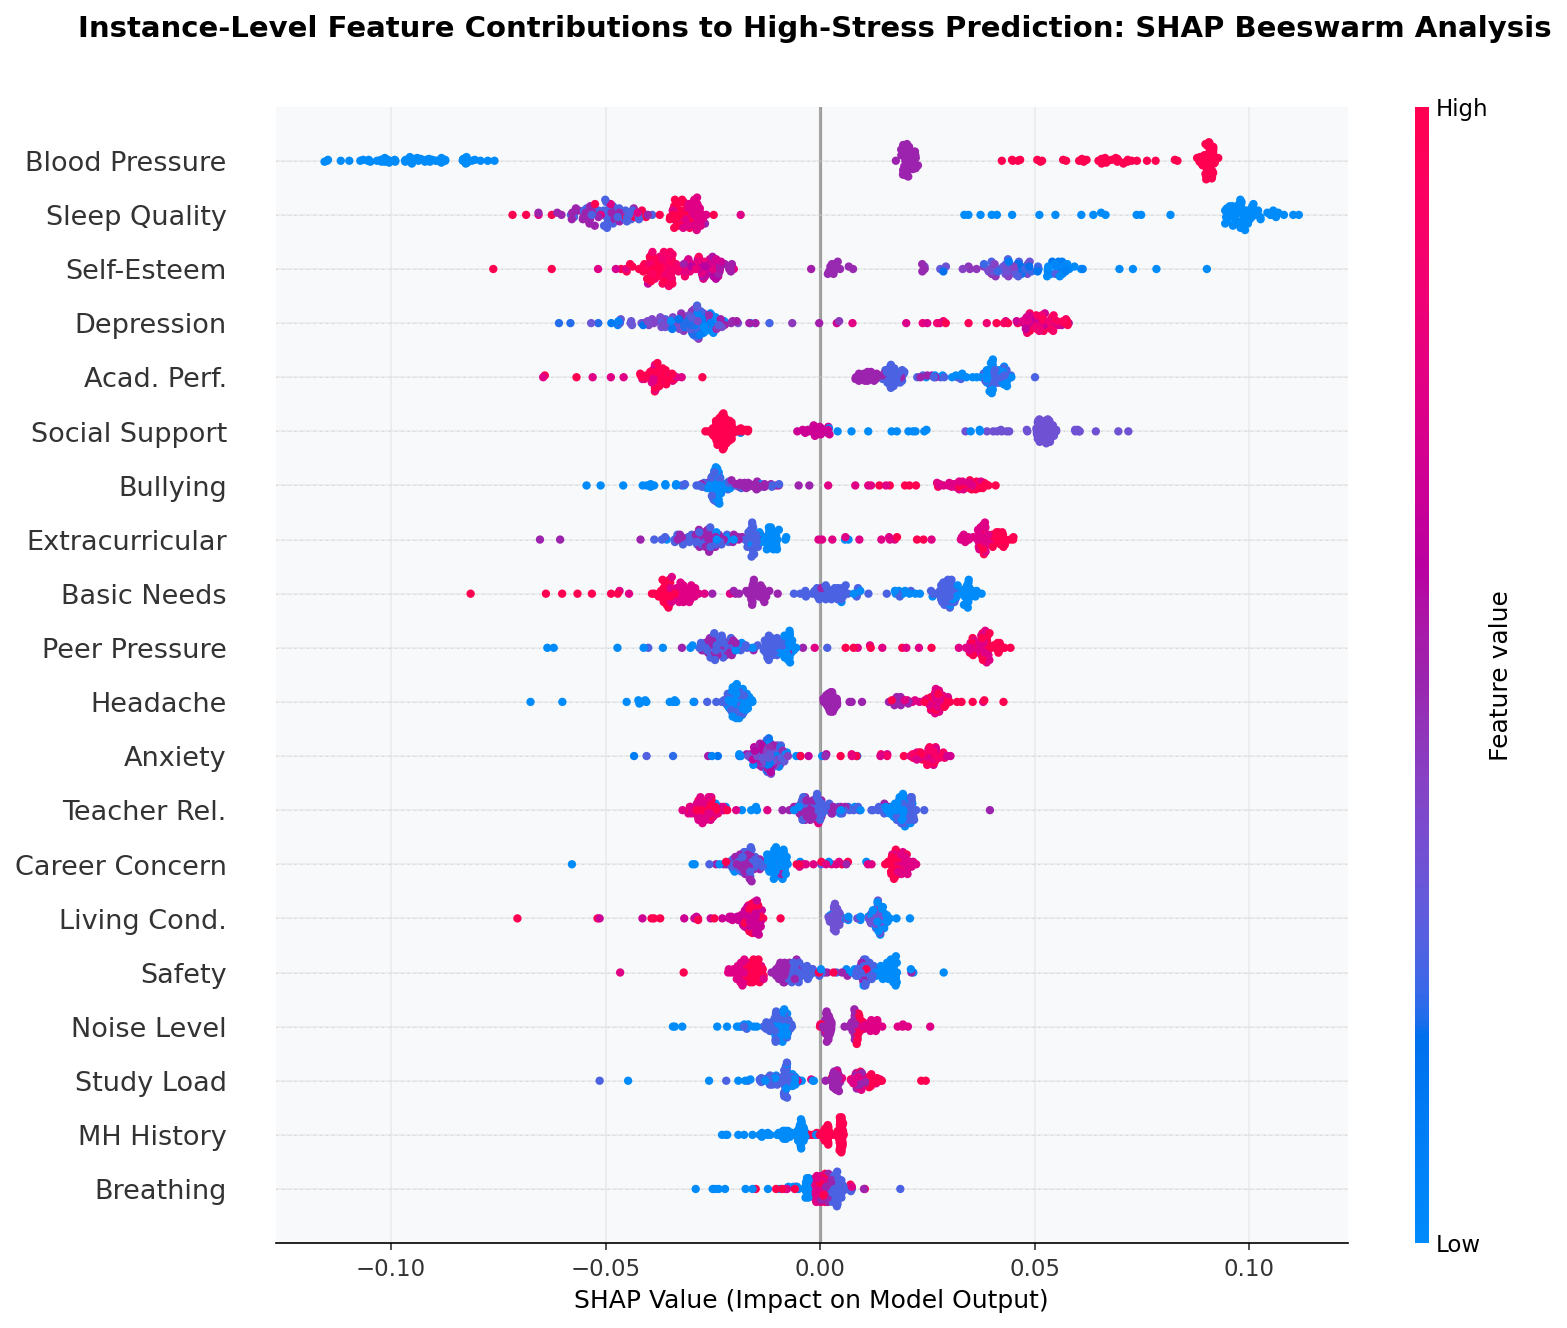

Figure 10 saved.


In [32]:
shap_high        = shap_arr[:, :, 2]
X_test_display   = X_test_s.copy()
X_test_display.columns = feature_names_clean

fig, ax = plt.subplots(figsize=(11, 9))
fig.suptitle(
    'Instance-Level Feature Contributions to High-Stress Prediction: SHAP Beeswarm Analysis\n',
    fontsize=14, fontweight='bold'
)
shap.summary_plot(shap_high, X_test_display,
                  feature_names=feature_names_clean,
                  max_display=20, plot_type='dot',
                  color_bar=True, show=False, plot_size=None)
plt.xlabel('SHAP Value (Impact on Model Output)', fontsize=12)
plt.tight_layout()
plt.savefig('fig10_shap_beeswarm.png', bbox_inches='tight', dpi=300)
plt.show()
print("Figure 10 saved.")

## FIGURE 11: SHAP Feature Importance Bar

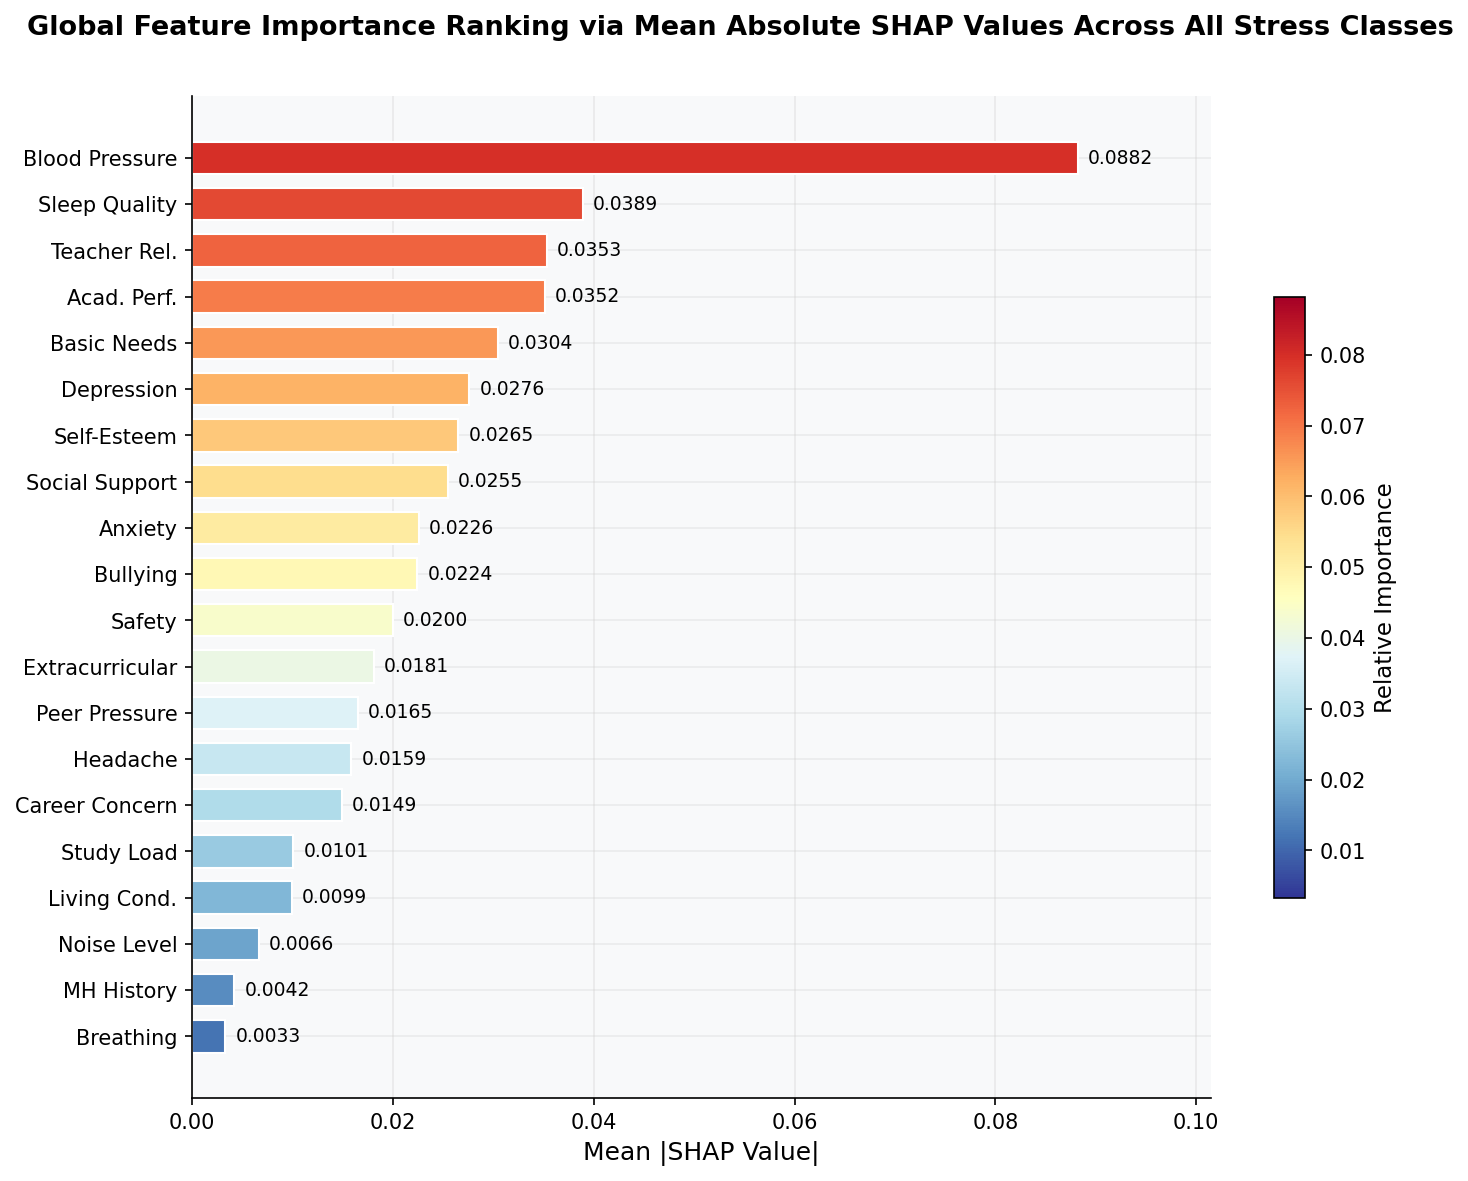

Figure 11 saved.


In [33]:
fig, ax = plt.subplots(figsize=(10, 8))
fig.suptitle(
    'Global Feature Importance Ranking via Mean Absolute SHAP Values Across All Stress Classes\n',
    fontsize=13, fontweight='bold'
)
mean_shap_sorted = mean_shap.sort_values(ascending=True)
n = len(mean_shap_sorted)
bar_colors_shap = plt.cm.RdYlBu_r(np.linspace(0.1, 0.9, n))

bars = ax.barh(mean_shap_sorted.index, mean_shap_sorted.values,
               color=bar_colors_shap, edgecolor='white', height=0.7)
for bar, val in zip(bars, mean_shap_sorted.values):
    ax.text(val + 0.001, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=9)

ax.set_xlabel('Mean |SHAP Value|', fontsize=12)
ax.set_xlim(0, mean_shap_sorted.max() * 1.15)
ax.grid(axis='x', alpha=0.35); ax.set_axisbelow(True)

sm = plt.cm.ScalarMappable(cmap=plt.cm.RdYlBu_r,
    norm=plt.Normalize(vmin=mean_shap_sorted.min(), vmax=mean_shap_sorted.max()))
sm.set_array([])
plt.colorbar(sm, ax=ax, shrink=0.6, label='Relative Importance')

plt.tight_layout()
plt.savefig('fig11_shap_importance.png', bbox_inches='tight', dpi=300)
plt.show()
print("Figure 11 saved.")

## FIGURE 12: Learning Curves  

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle(
    'Bias–Variance Characterisation Through Training and Validation Learning Trajectories\n',
    fontsize=14, fontweight='bold'
)
axes_flat   = axes.flatten()
train_sizes = np.linspace(0.1, 1.0, 10)

for ax, key in zip(axes_flat, keys):
    color = MODEL_COLORS[key]
    train_sz, train_sc, val_sc = learning_curve(
        models[key], X_train_s, y_train,
        train_sizes=train_sizes,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
        scoring='accuracy', n_jobs=-1
    )
    tr_m = train_sc.mean(1); tr_s = train_sc.std(1)
    va_m = val_sc.mean(1);   va_s = val_sc.std(1)

    ax.plot(train_sz, tr_m, 'o-', color=color, lw=2, label='Training')
    ax.fill_between(train_sz, tr_m - tr_s, tr_m + tr_s, alpha=0.15, color=color)
    ax.plot(train_sz, va_m, 's--', color='#555', lw=2, label='Validation CV')
    ax.fill_between(train_sz, va_m - va_s, va_m + va_s, alpha=0.12, color='#555')

    ax.set_title(model_full_names[key], fontsize=12, fontweight='bold',
                 color=color, pad=10)
    ax.axhline(ax.get_ylim()[1] if ax.get_ylim()[1] < 1.1 else 1.01,
               color=color, linewidth=3, alpha=0.4, xmin=0, xmax=1)

    ax.set_xlabel('Training Set Size', fontsize=10)
    ax.set_ylabel('Accuracy', fontsize=10)
    ax.set_ylim(0.70, 1.02)
    ax.legend(fontsize=9, loc='lower right')
    ax.grid(alpha=0.35); ax.set_axisbelow(True)

axes_flat[5].axis('off')
plt.tight_layout()
plt.savefig('fig12_learning_curves.png', bbox_inches='tight', dpi=300)
plt.show()
print("Figure 12 saved.")

In [28]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 17 — FINAL RESULTS TABLE
# ─────────────────────────────────────────────────────────────────────────────

print("=" * 80)
print("TABLE 1. Comparative Performance of ML Models on Test Set (Dataset 2)")
print("=" * 80)
table_metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC', 'MCC', 'Kappa']
df_table = pd.DataFrame(
    {model_full_names[k]: {m: f'{results[k][m]:.4f}' for m in table_metrics}
     for k in keys}
).T
df_table['CV Acc (mean±std)'] = [
    f"{results[k]['CV Acc Mean']:.4f} ± {results[k]['CV Acc Std']:.4f}" for k in keys
]
df_table.index.name = 'Model'
print(df_table.to_string())

best_acc = df_table['Accuracy'].astype(float).idxmax()
best_auc = df_table['AUC-ROC'].astype(float).idxmax()
print(f"\n  ★ Best by Accuracy : {best_acc}  ({df_table.loc[best_acc,'Accuracy']})")
print(f"  ★ Best by AUC-ROC  : {best_auc}  ({df_table.loc[best_auc,'AUC-ROC']})")

print("\n")
print("=" * 60)
print("ALL FIGURES GENERATED")
print("=" * 60)
figs_list = [
    ("fig1_stress_distribution.png",  "Stress distribution — before/after SMOTE + Dataset 2"),
    ("fig2_correlation_heatmap.png",  "Spearman Correlation Matrix (Dataset 2)"),
    ("fig3_boxplots_features.png",    "Feature Distributions by Stress Level"),
    ("fig4_model_comparison.png",     "Model Performance Comparison"),
    ("fig5_roc_curves.png",           "ROC Curves (macro avg, model-colour coded)"),
    ("fig6_confusion_matrices.png",   "Confusion Matrices (model-colour coded)"),
    ("fig7_cv_boxplots.png",          "10×5 RSKF Cross-Validation Boxplots"),
    ("fig8_shap_beeswarm.png",        "SHAP Beeswarm — High Stress class"),
    ("fig9_shap_importance.png",     "SHAP Feature Importance"),
    ("fig10_learning_curves.png",     "Learning Curves (model-colour coded)"),
]
for fname, desc in figs_list:
    print(f"  ✓  {fname:<38} — {desc}")

print(f"\nModel colour legend:")
for k in keys:
    print(f"  {MODEL_COLORS[k]}  →  {model_full_names[k]}")

TABLE 1. Comparative Performance of ML Models on Test Set (Dataset 2)
                    Accuracy Precision  Recall F1-Score AUC-ROC     MCC   Kappa CV Acc (mean±std)
Model                                                                                            
Logistic Regression   0.8818    0.8816  0.8818   0.8817  0.9853  0.8227  0.8227   0.8806 ± 0.0224
Random Forest         0.8909    0.8926  0.8909   0.8907  0.9830  0.8373  0.8364   0.8723 ± 0.0224
Gradient Boosting     0.8727    0.8730  0.8727   0.8722  0.9825  0.8098  0.8091   0.8783 ± 0.0232
SVM (RBF)             0.8773    0.8773  0.8773   0.8771  0.9845  0.8161  0.8159   0.8636 ± 0.0235
MLP Neural Network    0.8727    0.8739  0.8727   0.8721  0.9836  0.8102  0.8092   0.8690 ± 0.0222

  ★ Best by Accuracy : Random Forest  (0.8909)
  ★ Best by AUC-ROC  : Logistic Regression  (0.9853)


ALL FIGURES GENERATED
  ✓  fig1_stress_distribution.png           — Stress distribution — before/after SMOTE + Dataset 2
  ✓  fig2_correlatio